In [155]:
import pandas as pd
import numpy as np
from pycoingecko import CoinGeckoAPI
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.regression.linear_model import OLS
import math
# import talib

## Parameters

In [2]:
start_date = "2023-12-01"
end_date = "2024-12-01"

cg = CoinGeckoAPI()
top100_market_caps = cg.get_coins_markets(vs_currency='usd', order='market_cap_desc', per_page=100, page=1)
coins = [coin['symbol'].upper() + "-USD" for coin in top100_market_caps]

all_data = {}

## Download Data

In [3]:
all_data = pd.DataFrame()
for coin in coins:
    data = yf.download(coin, start=start_date, end=end_date, interval='1d')['Close']
    all_data[coin] = data

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

### To make sure about consistency, we need to drop nulls in prices list and also modify coins list.

In [4]:
# all_data.dropna(axis=1, how='all', inplace=True)
all_data.dropna(axis=1, how='any', inplace=True)
# all_data

In [5]:
for coin in coins:
    if coin not in all_data.columns:
        coins.remove(coin)

# Part 1

In [6]:
results_pvalue = {}
results_statistic = {}
results_critical_value = {}

idxs = []

for idx, coin in enumerate(coins):
    if coin not in all_data.columns:    # download failed or null data
        idxs.append(idx)
        continue

    series = all_data[coin].dropna()
    result = adfuller(series)
    adf_statistics = result[0]
    pvalue = result[1]
    critical_value = result[4]['5%']

    results_statistic[coin] = adf_statistics
    results_pvalue[coin] = pvalue 
    results_critical_value[coin] = critical_value

if len(idxs) != 0:
    idxs.reverse()
    for idx in idxs:
        coins.pop(idx)

### Stationary & Non-Stationary Coins

In [7]:
stationaries = all_data.copy(deep=True)
non_stationaries = all_data.copy(deep=True)
for coin in coins:
    if coin not in stationaries.columns:
        continue
    if results_pvalue[coin] >= 0.05 or results_statistic[coin] >= results_critical_value[coin]:
        stationaries.drop(coin, axis=1, inplace=True)
    else:
        non_stationaries.drop(coin, axis=1, inplace=True)
stationaries, non_stationaries

(                           USDT-USD  USDC-USD   DAI-USD   ARB-USD   TIA-USD  \
 Date                                                                          
 2023-12-01 00:00:00+00:00  1.000185  0.999797  0.999753  1.024856  0.003900   
 2023-12-02 00:00:00+00:00  1.000364  0.999953  1.000005  1.097355  0.002337   
 2023-12-03 00:00:00+00:00  1.000309  0.999896  0.999650  1.093913  0.002431   
 2023-12-04 00:00:00+00:00  0.999913  0.999921  1.000552  1.080965  0.002881   
 2023-12-05 00:00:00+00:00  1.000546  1.000284  1.000419  1.082039  0.008757   
 ...                             ...       ...       ...       ...       ...   
 2024-11-26 00:00:00+00:00  0.999654  1.000092  0.999839  0.000920  0.007825   
 2024-11-27 00:00:00+00:00  1.000994  0.999970  0.999871  0.000960  0.008822   
 2024-11-28 00:00:00+00:00  1.000154  1.000031  0.999879  0.000957  0.007998   
 2024-11-29 00:00:00+00:00  1.000366  0.999869  0.999741  0.000975  0.008009   
 2024-11-30 00:00:00+00:00  1.000630  1.

### Stationary by Pvalue

In [8]:
count = 0
for coin in coins:
    if results_pvalue[coin] < 0.05:
        count += 1
        print(f"{coin} is stationary with p-value: {results_pvalue[coin]}")

print(f"Total number of stationary coins: {count}")

USDT-USD is stationary with p-value: 4.1824937001870436e-07
USDC-USD is stationary with p-value: 4.46354493065218e-06
DAI-USD is stationary with p-value: 0.025146064505280844
ARB-USD is stationary with p-value: 0.028153719629105515
TIA-USD is stationary with p-value: 2.2600445329723208e-30
FDUSD-USD is stationary with p-value: 7.697228486460344e-08
BEAM-USD is stationary with p-value: 2.6629969392148403e-05
Total number of stationary coins: 7


### Stationary by Statistics

In [9]:
count = 0
for coin in coins:
    if results_statistic[coin] < results_critical_value[coin]:
        count += 1
        print(f"{coin} is stationary with adf-statistic: {results_statistic[coin]}")

print(f"Total number of stationary coins: {count}")

USDT-USD is stationary with adf-statistic: -5.821036890178164
USDC-USD is stationary with adf-statistic: -5.342719325719672
DAI-USD is stationary with adf-statistic: -3.11946163717742
ARB-USD is stationary with adf-statistic: -3.0789113535257773
TIA-USD is stationary with adf-statistic: -18.326774567587645
FDUSD-USD is stationary with adf-statistic: -6.1476584557208485
BEAM-USD is stationary with adf-statistic: -4.959874983554096
Total number of stationary coins: 7


### Stationary by Pvalue & Statistics

In [10]:
count = 0
for coin in coins:
    if results_pvalue[coin] < 0.05 and results_statistic[coin] < results_critical_value[coin]:
        count += 1
        print(f"{coin} is stationary with p-value: {results_pvalue[coin]} and statistic: {results_statistic[coin]}")

print(f"Total number of stationary coins: {count}")

USDT-USD is stationary with p-value: 4.1824937001870436e-07 and statistic: -5.821036890178164
USDC-USD is stationary with p-value: 4.46354493065218e-06 and statistic: -5.342719325719672
DAI-USD is stationary with p-value: 0.025146064505280844 and statistic: -3.11946163717742
ARB-USD is stationary with p-value: 0.028153719629105515 and statistic: -3.0789113535257773
TIA-USD is stationary with p-value: 2.2600445329723208e-30 and statistic: -18.326774567587645
FDUSD-USD is stationary with p-value: 7.697228486460344e-08 and statistic: -6.1476584557208485
BEAM-USD is stationary with p-value: 2.6629969392148403e-05 and statistic: -4.959874983554096
Total number of stationary coins: 7


# Part 2

In [11]:
def hurst_exponent(series: pd.Series) -> float:
    lags = range(2, 100)  
    tau = [np.std(series.diff(lag).dropna()) for lag in lags]
    log_tau = np.log(tau)
    log_lags = np.log(lags)
    
    hurst, _ = np.polyfit(log_lags, log_tau, 1)
    return hurst

In [200]:
def half_life(series: pd.Series) -> float:
    lagged_series = series.shift(1).dropna()[1:]
    delta_series = series.diff().dropna()[1:]
    
    lagged_series_with_const = sm.add_constant(lagged_series)
    
    model = sm.OLS(delta_series, lagged_series_with_const)
    result = model.fit()
    
    beta = result.params[1]
    
    halflife = -np.log(2) / beta
    
    return halflife

In [201]:
hurst_exponents = {}
half_lives = {}

### Calculate the Half Life and Hurst Exponent of Stationary Coins

In [202]:
for coin in stationaries.columns:
    hurst_exponents[coin] = hurst_exponent(stationaries[coin])
    half_lives[coin] = half_life(stationaries[coin])

### Plot the Price of Stationary Coins Sorted by Hurst Exponent

DAI-USD has a Hurst Exponent of -0.023498129071581067 and a Half-Life of 0.8776256572243434
FDUSD-USD has a Hurst Exponent of 0.003594978964996424 and a Half-Life of 1.8302086784986933
USDC-USD has a Hurst Exponent of 0.010250409317962495 and a Half-Life of 1.1040915711012096
TIA-USD has a Hurst Exponent of 0.047878399817957454 and a Half-Life of 0.7211350158307172
USDT-USD has a Hurst Exponent of 0.08105206925310053 and a Half-Life of 2.8055178495926425
ARB-USD has a Hurst Exponent of 0.09021173691631419 and a Half-Life of 3.4711749843800543
BEAM-USD has a Hurst Exponent of 0.3396968396322088 and a Half-Life of 21.15112558188731


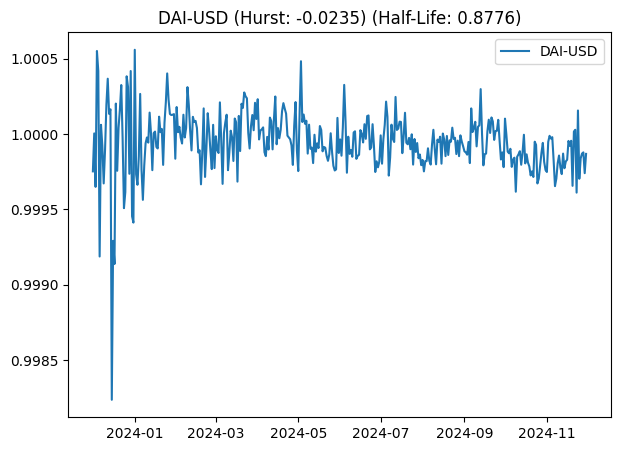

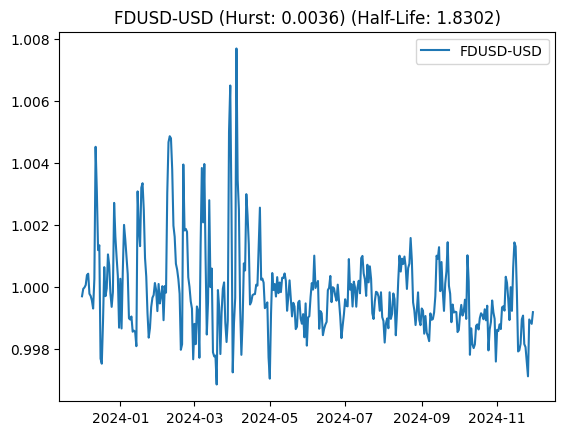

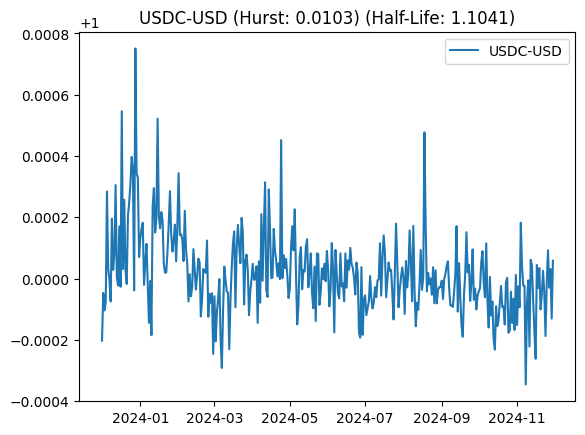

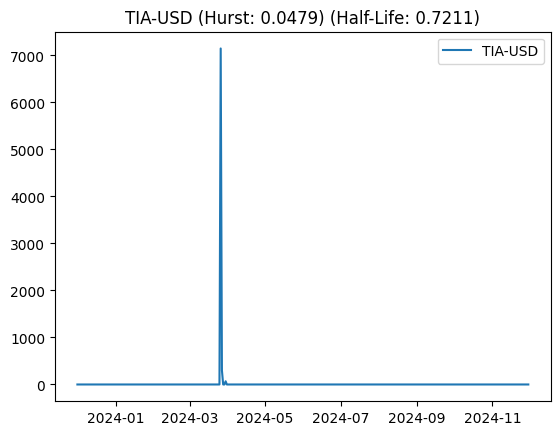

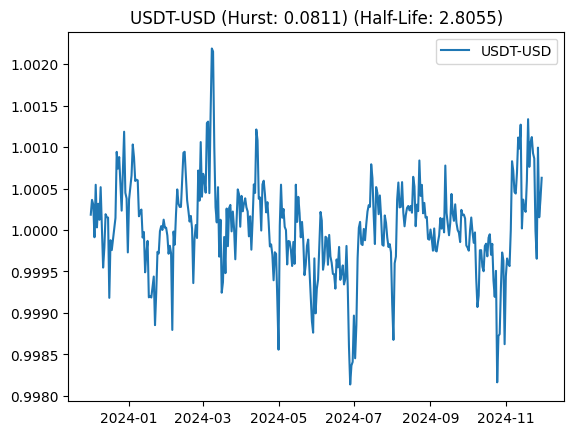

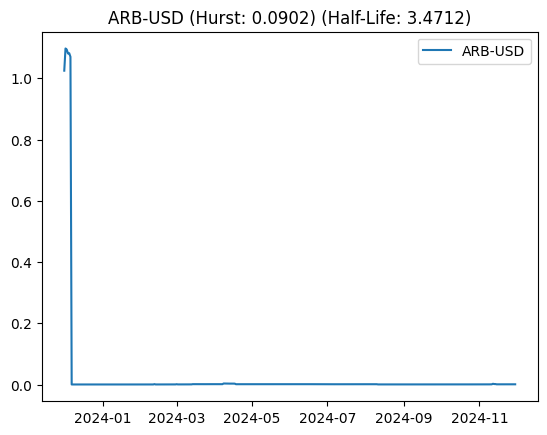

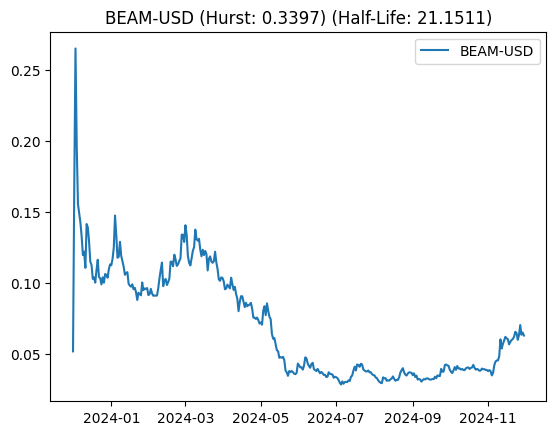

In [203]:
hurst_sorted = sorted(hurst_exponents.items(), key=lambda item: item[1])

for coin, hurst in hurst_sorted:
    print(f"{coin} has a Hurst Exponent of {hurst} and a Half-Life of {half_lives[coin]}")
    
plt.figure(figsize=(7, 5))
for i, (coin, hurst) in enumerate(hurst_sorted):
    plt.plot(stationaries[coin], label=f"{coin}")
    plt.legend()
    plt.title(f"{coin} (Hurst: {hurst:.4f}) (Half-Life: {half_lives[coin]:.4f})")
    plt.show()

# Part 3

In [192]:
def find_cointegrated_pairs(coin_1: pd.Series, coin_2:pd.Series) -> float:
    coin_1_series = non_stationaries[coin_1].dropna()
    coin_2_series = non_stationaries[coin_2].dropna()

    result = coint(coin_1_series, coin_2_series, maxlag=5)
    pvalue = result[1]
    
    return pvalue

In [193]:
cointegrated_pairs = []

for coin_1 in non_stationaries.columns:
    for coin_2 in non_stationaries.columns:
        if coin_1 == coin_2:
            continue

        pvalue = find_cointegrated_pairs(coin_1, coin_2)
        if pvalue < 0.05:
            model = OLS(non_stationaries[coin_1], non_stationaries[coin_2])
            fitted_model = model.fit()
            beta = fitted_model.params[coin_2]
            pair = (coin_1, coin_2, pvalue, beta)
            cointegrated_pairs.append(pair)

In [194]:
hurst_results = []
combined_series = []

for pair in cointegrated_pairs:
    coin_1 = pair[0]
    coin_2 = pair[1]
    pvalue = pair[2]
    beta = pair[3]

    coin_1_series = non_stationaries[coin_1]
    coin_2_series = non_stationaries[coin_2]

    combined_serie = coin_1_series - beta * coin_2_series
    combined_series.append((coin_1, coin_2, combined_serie))
    hurst = hurst_exponent(combined_serie)
    hurst_results.append((coin_1, coin_2, pvalue, beta, hurst))

In [195]:
hurst_sorted = sorted(hurst_results, key=lambda x: x[4])[:10]

1. ETH-USD & STETH-USD - β: 1.0007, Hurst: 0.0079
2. STETH-USD & ETH-USD - β: 0.9993, Hurst: 0.0079
3. WETH-USD & STETH-USD - β: 1.0009, Hurst: 0.0187
4. STETH-USD & WETH-USD - β: 0.9991, Hurst: 0.0187
5. OM-USD & RAY-USD - β: 0.4802, Hurst: 0.0225
6. ETH-USD & WETH-USD - β: 0.9998, Hurst: 0.0240
7. WETH-USD & ETH-USD - β: 1.0002, Hurst: 0.0240
8. OKB-USD & QNT-USD - β: 0.5063, Hurst: 0.0401
9. XTZ-USD & SAND-USD - β: 2.1244, Hurst: 0.0405
10. QNT-USD & OKB-USD - β: 1.9523, Hurst: 0.0408


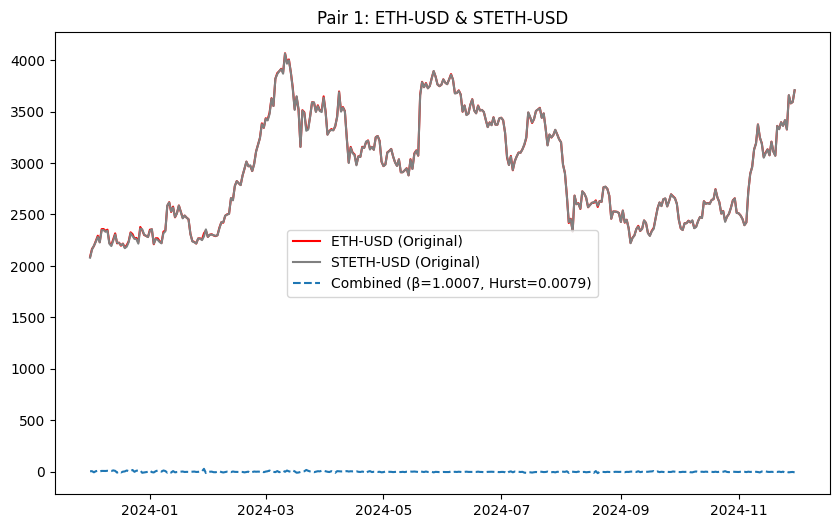

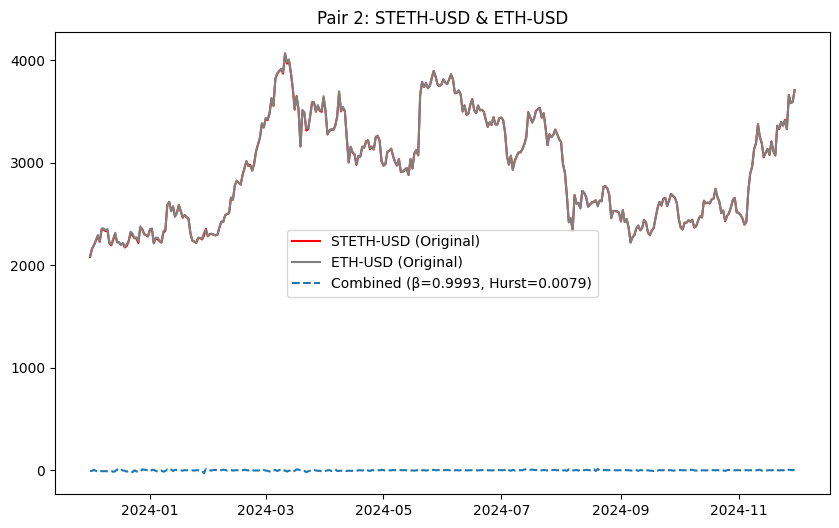

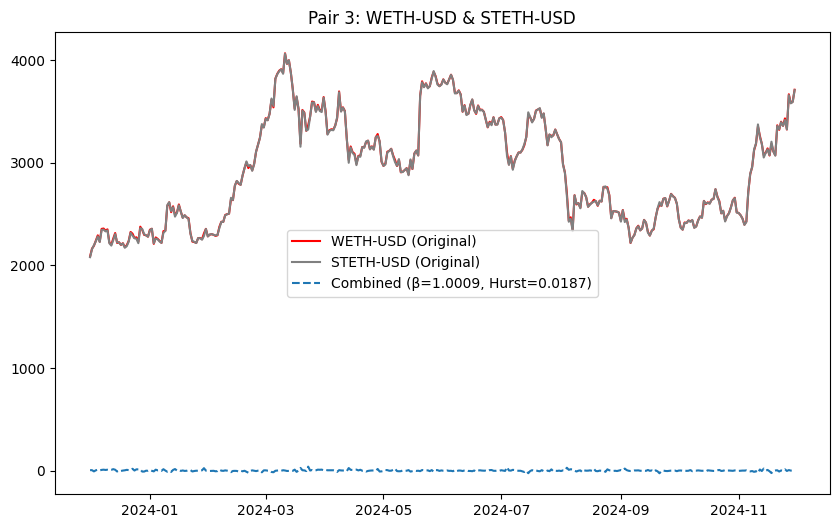

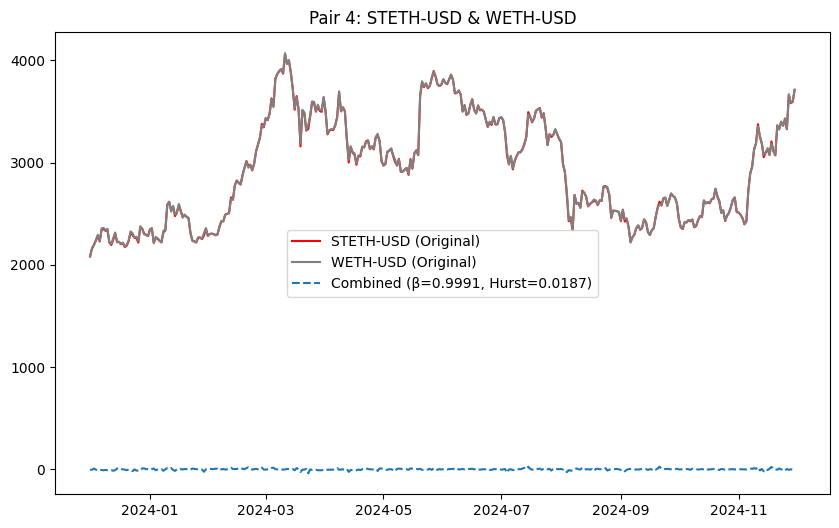

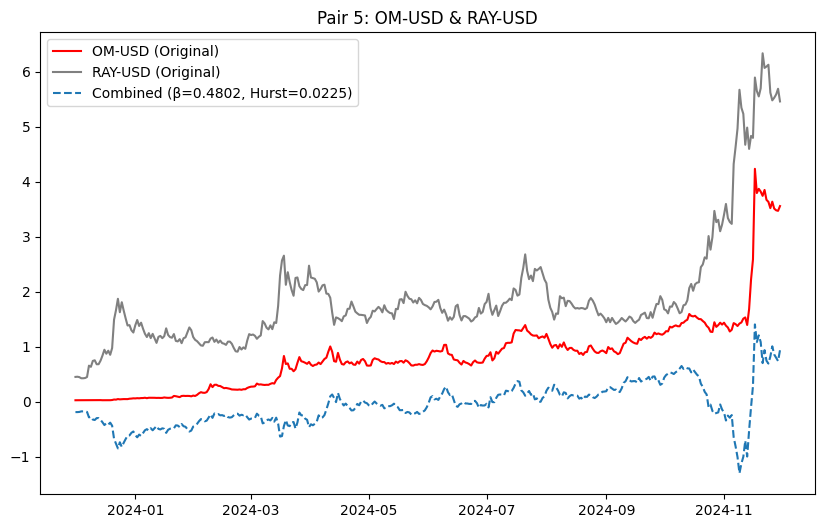

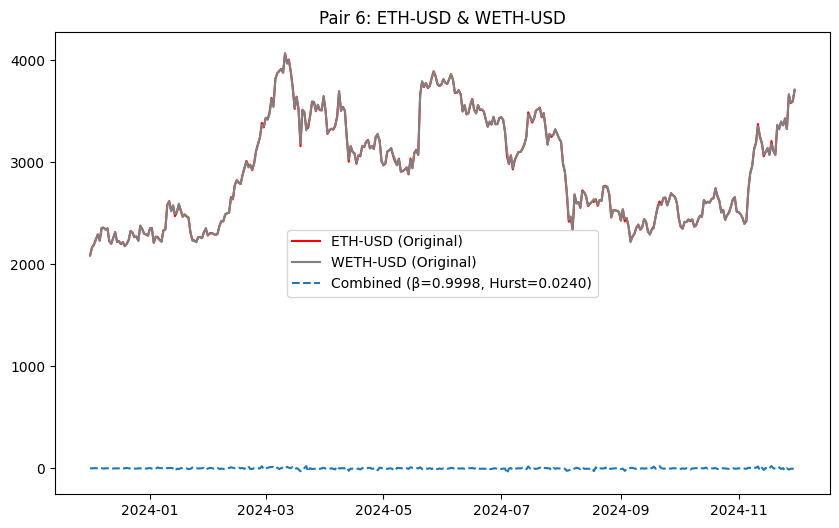

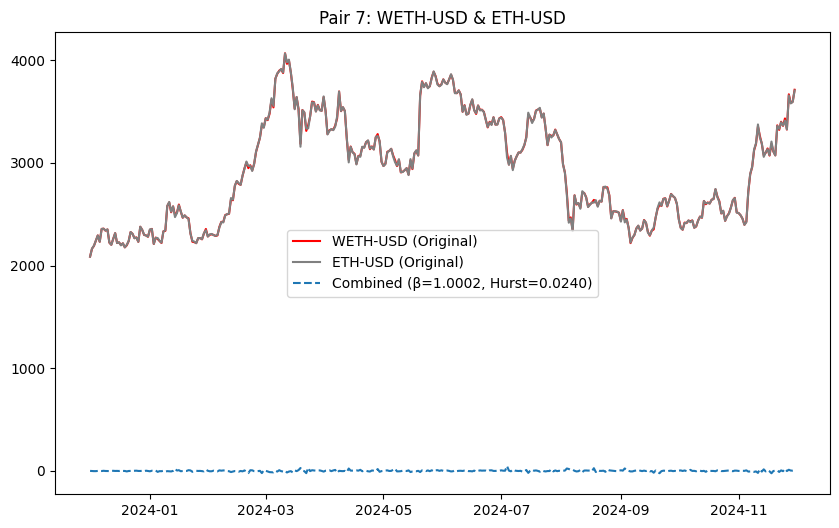

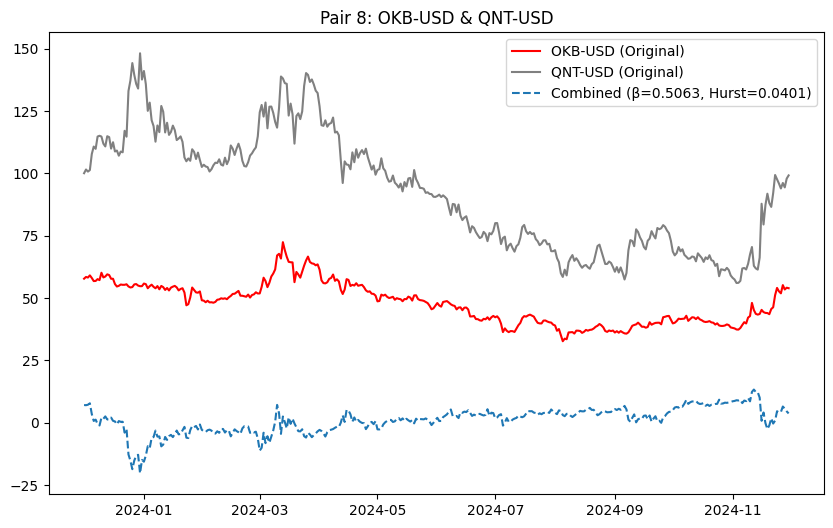

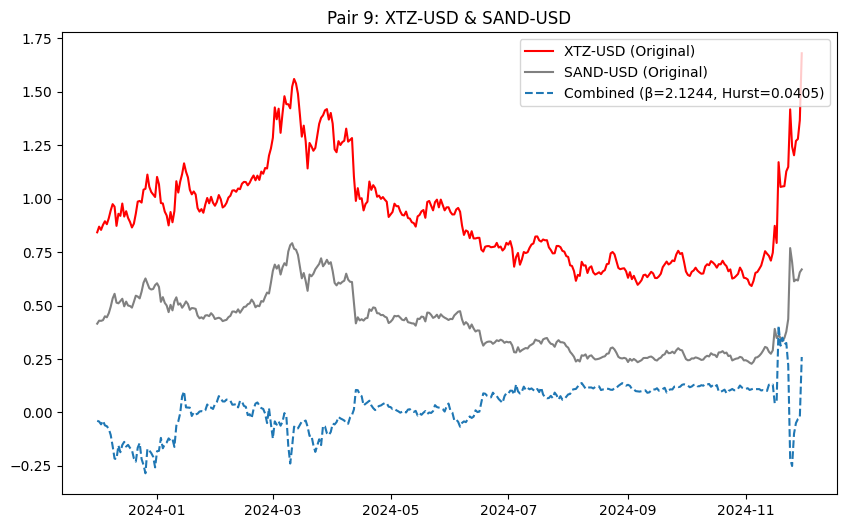

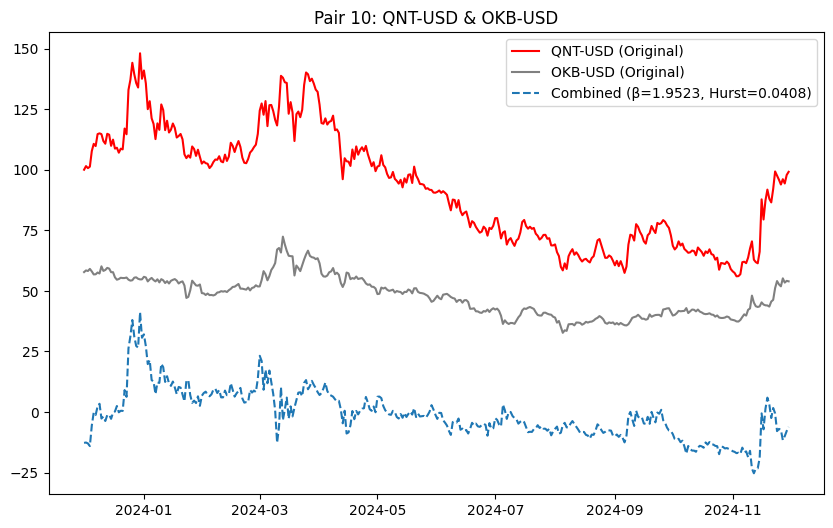

In [196]:
for i, (coin_1, coin_2, pvalue, beta, hurst) in enumerate(hurst_sorted):
    print(f"{i + 1}. {coin_1} & {coin_2} - β: {beta:.4f}, Hurst: {hurst:.4f}")

for i, (coin_1, coin_2, pvalue, beta, hurst) in enumerate(hurst_sorted):
    series1 = non_stationaries[coin_1]
    series2 = non_stationaries[coin_2]
    combined_series = series1 - beta * series2
    
    plt.figure(figsize=(10, 6))
    plt.plot(series1, label=f"{coin_1} (Original)", color='red')
    plt.plot(series2, label=f"{coin_2} (Original)", color='gray')
    plt.plot(combined_series, label=f"Combined (β={beta:.4f}, Hurst={hurst:.4f})", linestyle='--')
    plt.title(f"Pair {i + 1}: {coin_1} & {coin_2}")
    plt.legend()
    plt.show()

# Strategy & Backtest

### Extracting New Combined Series of non-Stationary Coins

In [197]:
combined_coins_beta = [(coin_1, coin_2, beta) for coin_1, coin_2, _, beta, _ in hurst_sorted]

combined_series_df = pd.DataFrame(index=non_stationaries.index)
for item in combined_coins_beta:
    coin_1 = item[0]
    coin_2 = item[1]
    beta = item[2]
    combined_series_df[f"{coin_1}//{coin_2}"] = non_stationaries[coin_1].values - beta * non_stationaries[coin_2].values
    
combined_series_df

,ETH-USD//STETH-USD,STETH-USD//ETH-USD,WETH-USD//STETH-USD,STETH-USD//WETH-USD,OM-USD//RAY-USD,ETH-USD//WETH-USD,WETH-USD//ETH-USD,OKB-USD//QNT-USD,XTZ-USD//SAND-USD,QNT-USD//OKB-USD
Date,,,,,,,,,,
2023-12-01 00:00:00+00:00,5.062552,-5.053373,4.680817,-4.663651,-0.191787,0.392942,-0.379600,7.130777,-0.039329,-12.757884
2023-12-02 00:00:00+00:00,5.799993,-5.790077,4.014999,-3.997930,-0.192173,1.796481,-1.782864,7.060024,-0.042881,-12.602438
2023-12-03 00:00:00+00:00,-5.096892,5.099107,-7.736952,7.743937,-0.189364,2.649813,-2.636157,7.252096,-0.055887,-12.987172
2023-12-04 00:00:00+00:00,5.592685,-5.582711,2.989167,-2.972513,-0.179208,2.615226,-2.601247,7.812774,-0.039390,-14.074649
2023-12-05 00:00:00+00:00,9.334380,-9.321601,8.592539,-8.570667,-0.178746,0.754704,-0.740094,3.510810,-0.060905,-5.601120
...,...,...,...,...,...,...,...,...,...,...
2024-11-26 00:00:00+00:00,-1.761415,1.769032,-3.541239,3.558991,1.004640,1.795927,-1.774854,4.345551,-0.099655,-7.391333
2024-11-27 00:00:00+00:00,-5.482955,5.488799,5.117574,-5.090116,0.856148,-10.581327,10.606557,6.527879,-0.049636,-11.626313
2024-11-28 00:00:00+00:00,-2.886056,2.893546,0.047038,-0.024537,0.796577,-2.915126,2.938599,5.672461,-0.031567,-9.976918


In [204]:
def find_lookback(halflife: float) -> int:
    lookback = halflife
    mult = 2
    while lookback < 20:
        lookback = halflife * mult
        mult += 1
    return int(lookback * math.ceil(20 / lookback))

In [89]:
def sharpe_ratio(equity: pd.Series, risk_free_rate:float = 0.04) -> float:
    daily_returns = equity.pct_change().dropna()
    excess_returns = daily_returns - (risk_free_rate / 252)
    annualized_return = excess_returns.mean() * 252
    annualized_volatility = daily_returns.std() * np.sqrt(252)
    return annualized_return / annualized_volatility

In [153]:
def plot_backtest_results(combination, serie: pd.DataFrame, equity: pd.Series):
    """
    Plot the price, EMA, bounds, buy/sell signals, and equity curve.

    Parameters:
    - serie: DataFrame containing price, EMA, bounds, and buy/sell signals.
    - equity: Series representing the equity curve over time.
    """
    plt.figure(figsize=(14, 8))
    
    # Plot price, EMA, and bounds
    plt.plot(serie.index, serie["price"], label="Price", color="blue", alpha=0.6)
    plt.plot(serie.index, serie["ema"], label="EMA", color="gold", linestyle="--", alpha=0.8)
    plt.plot(serie.index, serie["up1"], label="Upper Bound (1 SD)", color="purple", linestyle=":")
    plt.plot(serie.index, serie["up2"], label="Upper Bound (2 SD)", color="green", linestyle="-")
    plt.plot(serie.index, serie["up3"], label="Upper Bound (3 SD)", color="red", linestyle="--")
    plt.plot(serie.index, serie["down1"], label="Lower Bound (1 SD)", color="purple", linestyle=":")
    plt.plot(serie.index, serie["down2"], label="Lower Bound (2 SD)", color="green", linestyle="-")
    plt.plot(serie.index, serie["down3"], label="Lower Bound (3 SD)", color="red", linestyle="--")

    # Highlight buy/sell signals
    buy_signals = serie[serie["buy"] == 1]
    sell_signals = serie[serie["sell"] == 1]
    buy_exits = serie[serie["buy"] == -1]
    sell_exits = serie[serie["sell"] == -1]

    plt.scatter(buy_signals.index, buy_signals["price"], color="green", marker="^", label="Buy Entry", zorder=5)
    plt.scatter(sell_signals.index, sell_signals["price"], color="red", marker="v", label="Sell Entry", zorder=5)
    plt.scatter(buy_exits.index, buy_exits["price"], color="lime", marker="o", label="Buy Exit", zorder=5)
    plt.scatter(sell_exits.index, sell_exits["price"], color="orange", marker="o", label="Sell Exit", zorder=5)

    # Plot equity curve
    plt.figure(figsize=(14, 4))
    plt.plot(equity.index, equity, label="Equity Curve", color="purple", alpha=0.8)
    plt.title(f"{combination} Equity Curve")
    plt.xlabel("Date")
    plt.ylabel("Equity")
    plt.legend()
    plt.grid()

    # Finalize the plot
    plt.figure(1)
    plt.title(f"{combination} Price, EMA, Bounds, and Signals")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid()
    plt.show()

In [150]:
def ema_custom(data, lookback):
    alpha = 2 / (lookback + 1)
    ema = [data[0]]
    for price in data[1:]:
        ema.append(alpha * price + (1 - alpha) * ema[-1])
    return ema

In [149]:
def ewm_std_custom(data, lookback):
    alpha = 2 / (lookback + 1)
    data = np.array(data)
    
    ewm_mean = ema_custom(data, lookback)
    squared_deviations = (data - ewm_mean) ** 2
    ewm_var = ema_custom(squared_deviations, lookback)
    ewm_std = np.sqrt(ewm_var)
    
    return ewm_std

In [146]:
def backtest(price: pd.Series, lookback: int, initial_cap: float=100) -> tuple:
    index = price.index
    equity = pd.Series(index=index)
    equity.iloc[0] = initial_cap

    # ema = series.ewm(span=lookback, min_periods=1).mean()
    # ema = talib.EMA(price, timeperiod=lookback)
    # std = series.rolling(window=lookback, min_periods=lookback).std()
    ema = ema_custom(price, lookback)
    std = ewm_std_custom(price, lookback)

    serie = pd.DataFrame(columns=["price", "ema", "std"], index=price.index)
    serie["price"] = price
    serie["ema"] = ema
    serie["std"] = std

    serie["up1"] = serie["ema"] + serie["std"]
    serie["up2"] = serie["ema"] + 2 * serie["std"]
    serie["up3"] = serie["ema"] + 3 * serie["std"]
    serie["down1"] = serie["ema"] - serie["std"]
    serie["down2"] = serie["ema"] - 2 * serie["std"]
    serie["down3"] = serie["ema"] - 3 * serie["std"]

    balance = initial_cap
    position = 0    # 0: no position, 0.5: long, 1: full long, -0.5: short, -1: full short
    serie["sell"] = 0   # 1: sell, -1: exit sell
    serie["buy"] = 0    # 1: buy, -1: exit buy

    sell_entry_half_price = 0
    sell_entry_full_price = 0

    for datetime in index:
        # enter position
        if position == 0:
            if serie.loc[datetime, "price"] > serie.loc[datetime, "up2"]:
                # print("Enter sell position (-0.5)! Price:", serie.loc[datetime, "price"])
                position = -0.5
                serie.loc[datetime, "sell"] = 1
                sell_entry_half_price = serie.loc[datetime, "price"]
                balance -= position * serie.loc[datetime, "price"]

            elif serie.loc[datetime, "price"] < serie.loc[datetime, "down2"]:
                # print("Enter buy position (0.5)! Price:", serie.loc[datetime, "price"])
                position = 0.5
                serie.loc[datetime, "buy"] = 1
                balance -= position * serie.loc[datetime, "price"]

        elif position == 0.5:
            if serie.loc[datetime, "price"] < serie.loc[datetime, "down3"]:
                # print("Enter buy position (1)! Price:", serie.loc[datetime, "price"])
                position = 1
                serie.loc[datetime, "buy"] = 1
                balance -= 0.5 * serie.loc[datetime, "price"]

        elif position == -0.5:
            if serie.loc[datetime, "price"] > serie.loc[datetime, "up3"]:
                # print("Enter sell position (-1)! Price:", serie.loc[datetime, "price"])
                position = -1
                serie.loc[datetime, "sell"] = 1
                sell_entry_full_price = serie.loc[datetime, "price"]
                balance -= 0.5 * serie.loc[datetime, "price"]

        # exit position
        if position != 0:
            if position < 0 and serie.loc[datetime, "price"] < serie.loc[datetime, "up1"]:
                # print("Exit sell position! Price:", serie.loc[datetime, "price"])
                balance -= position * serie.loc[datetime, "price"]
                position = 0
                serie.loc[datetime, "sell"] = -1
            elif position > 0 and serie.loc[datetime, "price"] > serie.loc[datetime, "down1"]:
                # print("Exit buy position! Price:", serie.loc[datetime, "price"])
                balance += position * serie.loc[datetime, "price"]
                position = 0
                serie.loc[datetime, "buy"] = -1

        if position == 0:
            equity.loc[datetime] = balance
        elif position > 0:
            equity.loc[datetime] = position * serie.loc[datetime, "price"] + balance
        else:
            if position == -0.5:
                equity.loc[datetime] = position * (sell_entry_half_price - serie.loc[datetime, "price"]) + balance
            else:
                equity.loc[datetime] = position * (sell_entry_half_price + sell_entry_full_price - 2 * serie.loc[datetime, "price"]) + balance
        
    return equity, serie

# Part 4 & 5

halflife: 0.9033752847534643 Lookback: 20
Sharpe:  2.3807679125929297


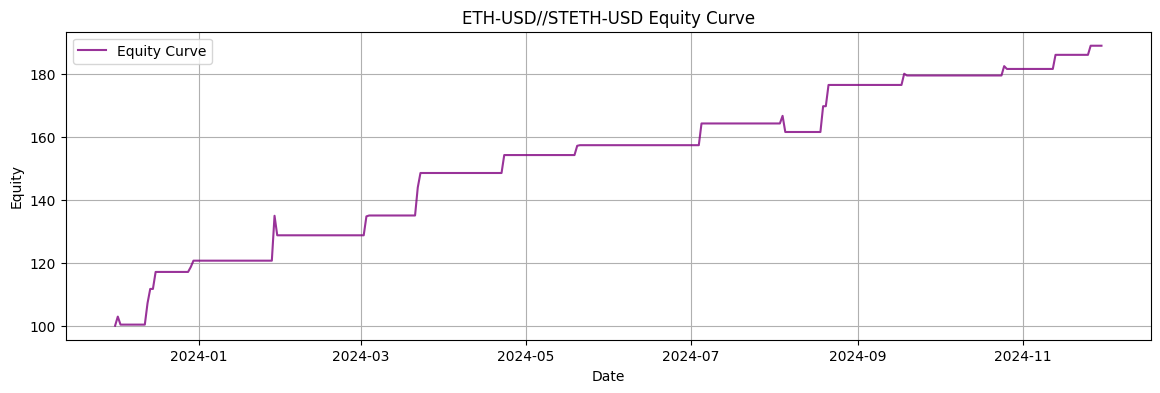

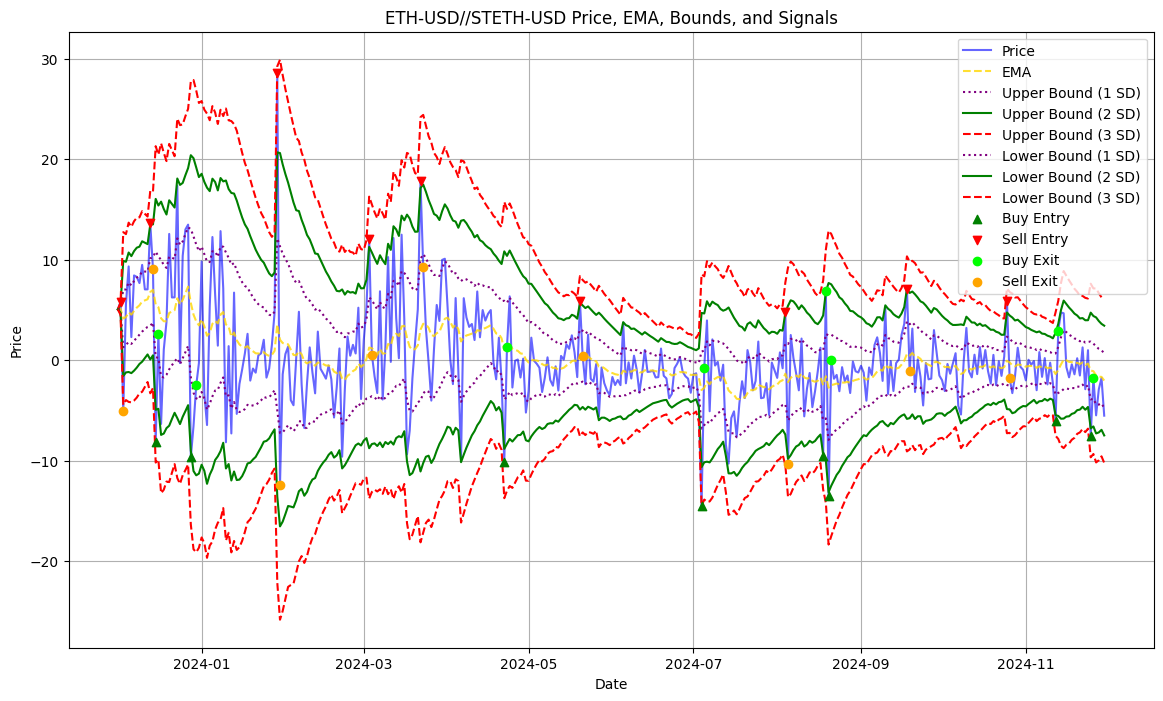

halflife: 0.9034263226130731 Lookback: 20
Sharpe:  2.279865559169715


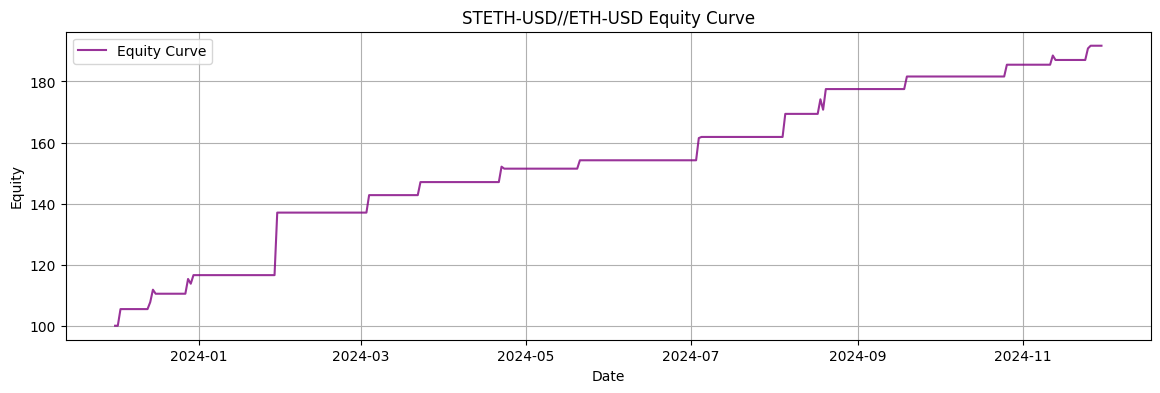

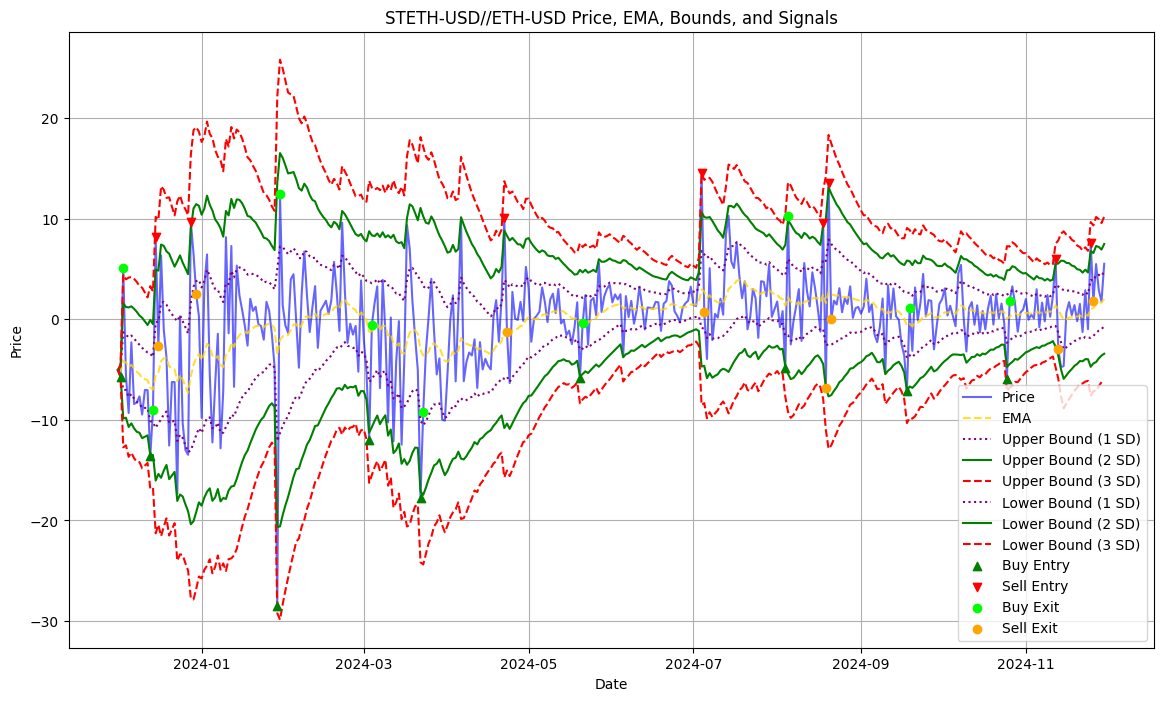

halflife: 0.7864234288558599 Lookback: 20
Sharpe:  3.2618391803387614


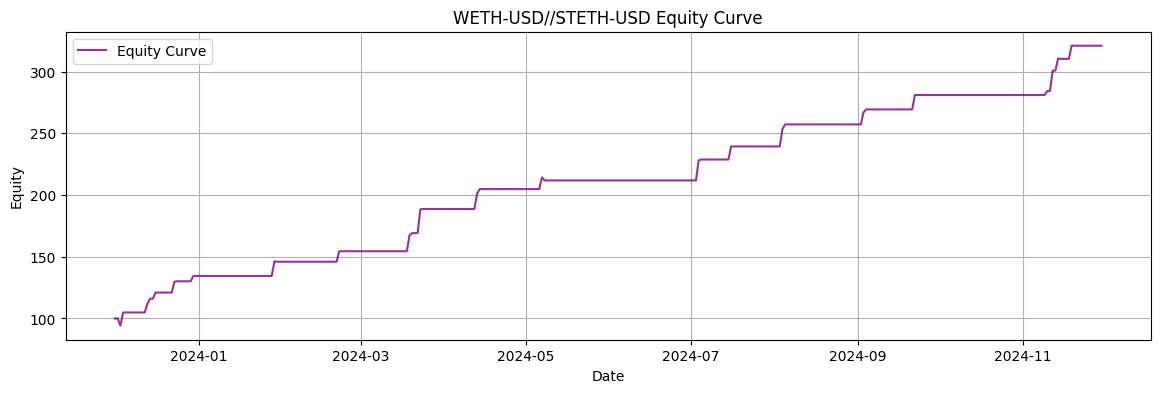

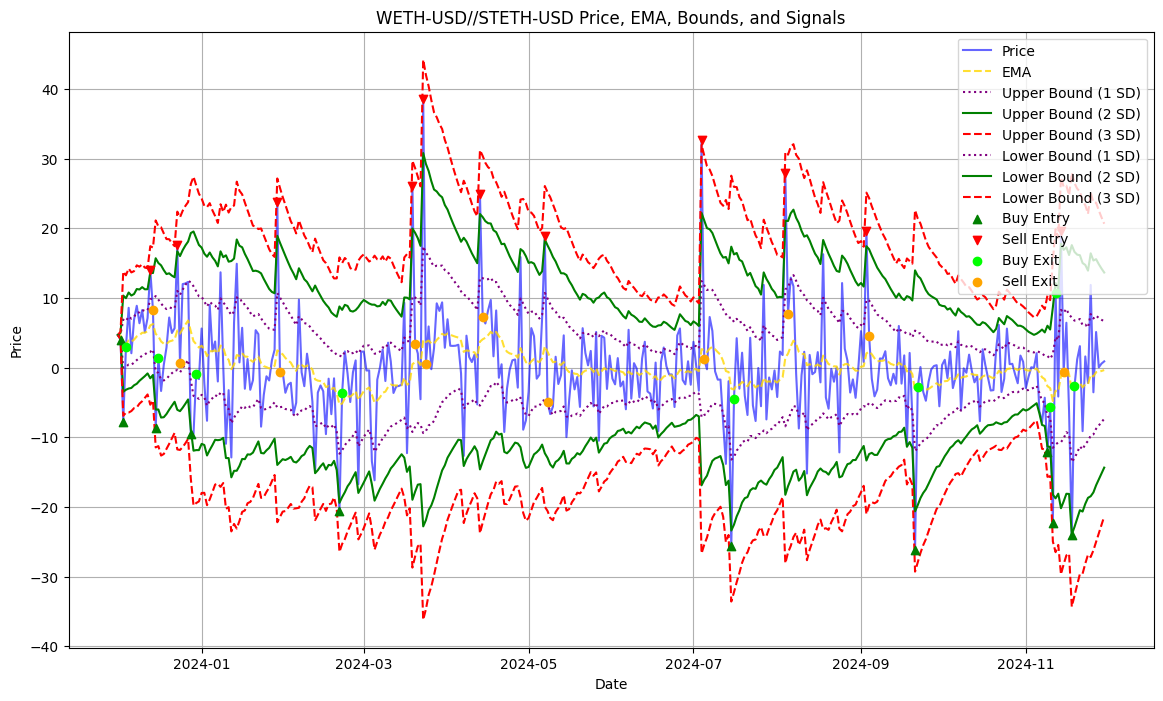

halflife: 0.7864630319035616 Lookback: 20
Sharpe:  2.6422403365773808


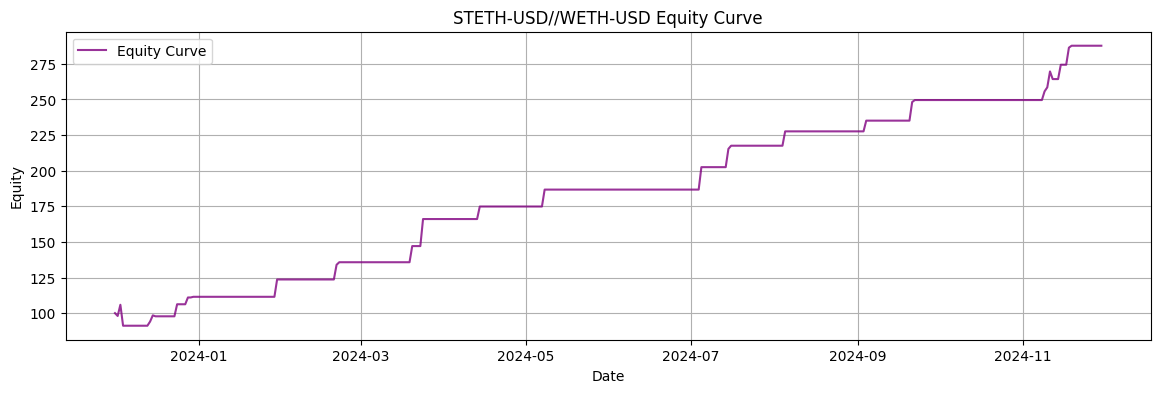

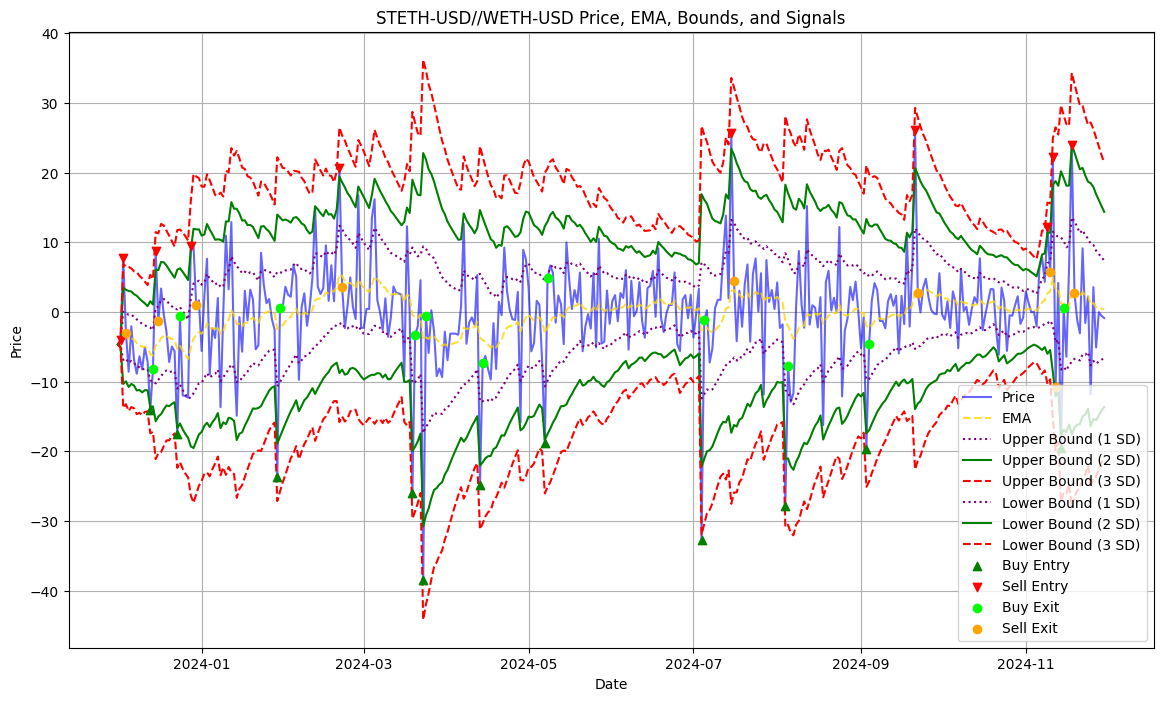

halflife: 24.385218310054317 Lookback: 24
Sharpe:  -3.615209948571191


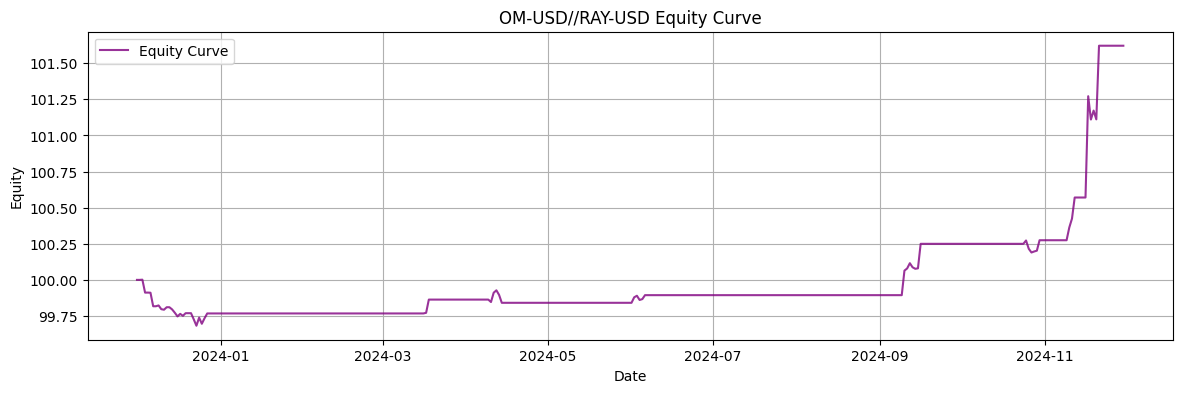

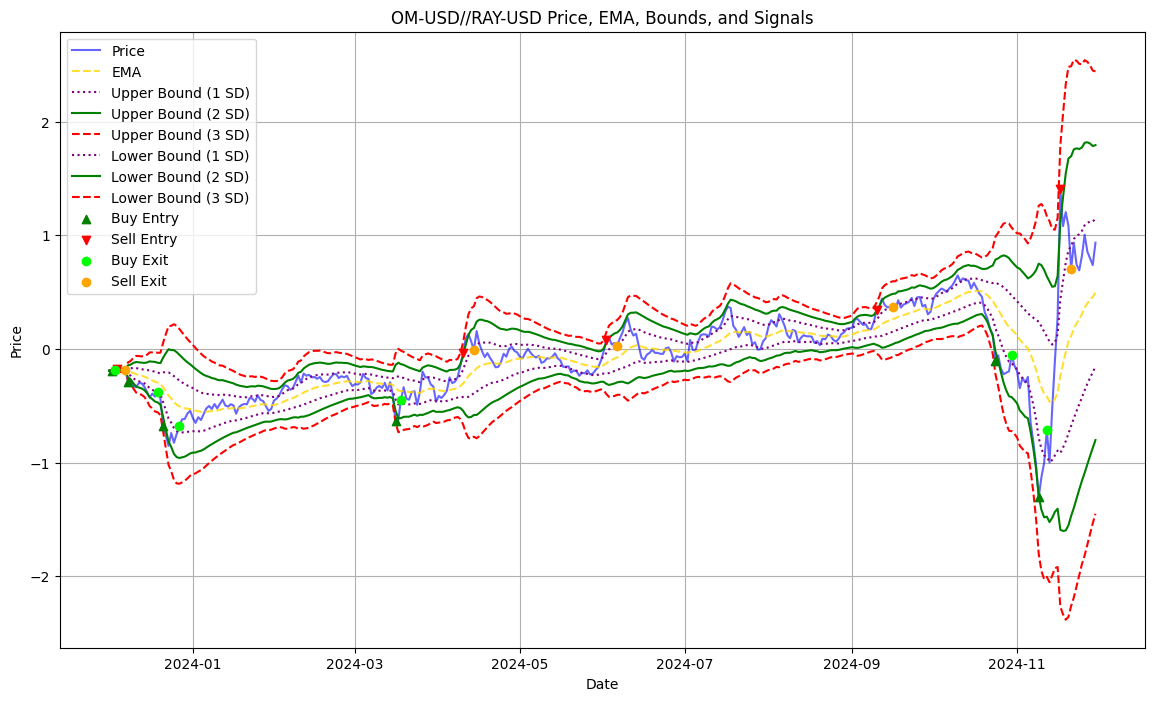

halflife: 0.677883620039136 Lookback: 20
Sharpe:  3.3167657987794987


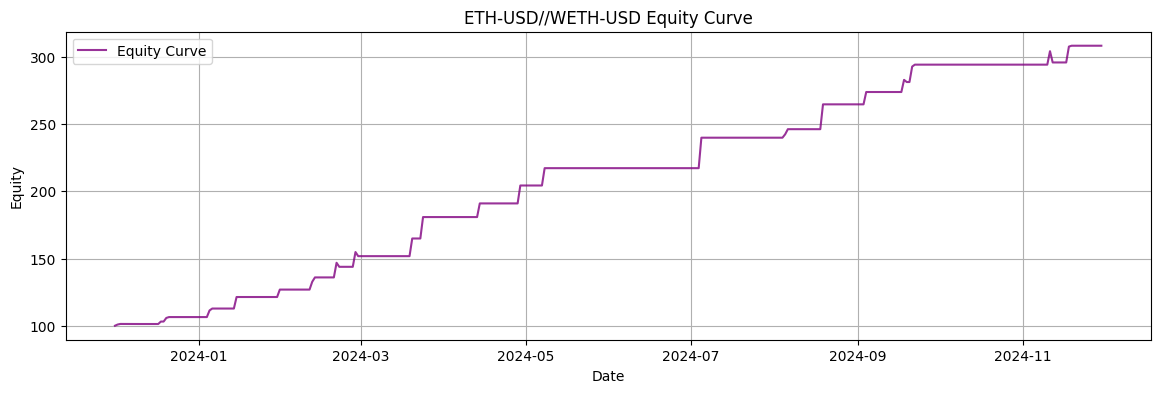

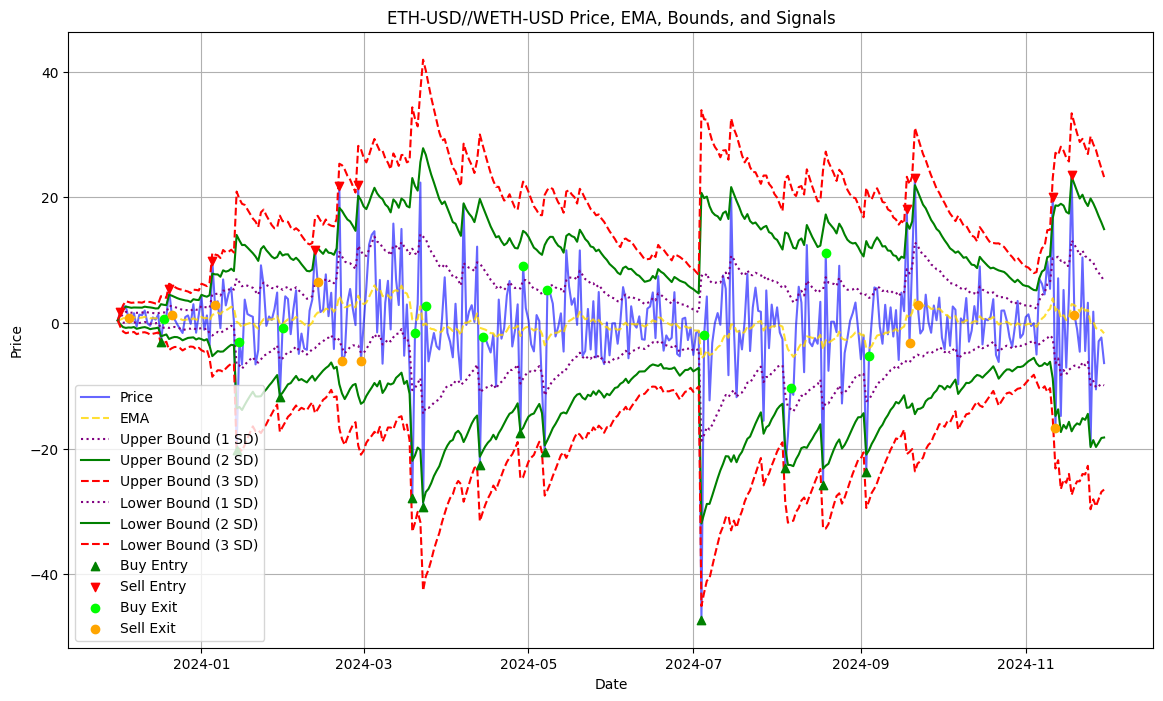

halflife: 0.6778851608323997 Lookback: 20
Sharpe:  3.2651726348249293


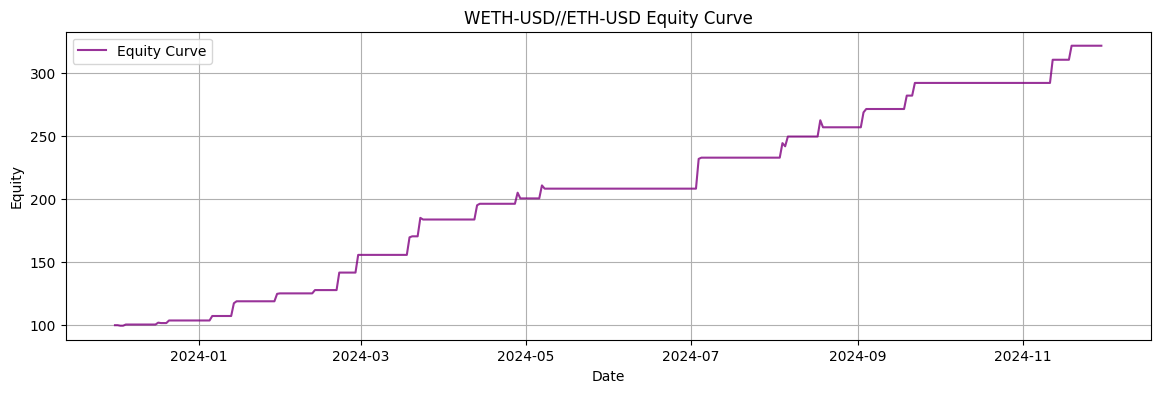

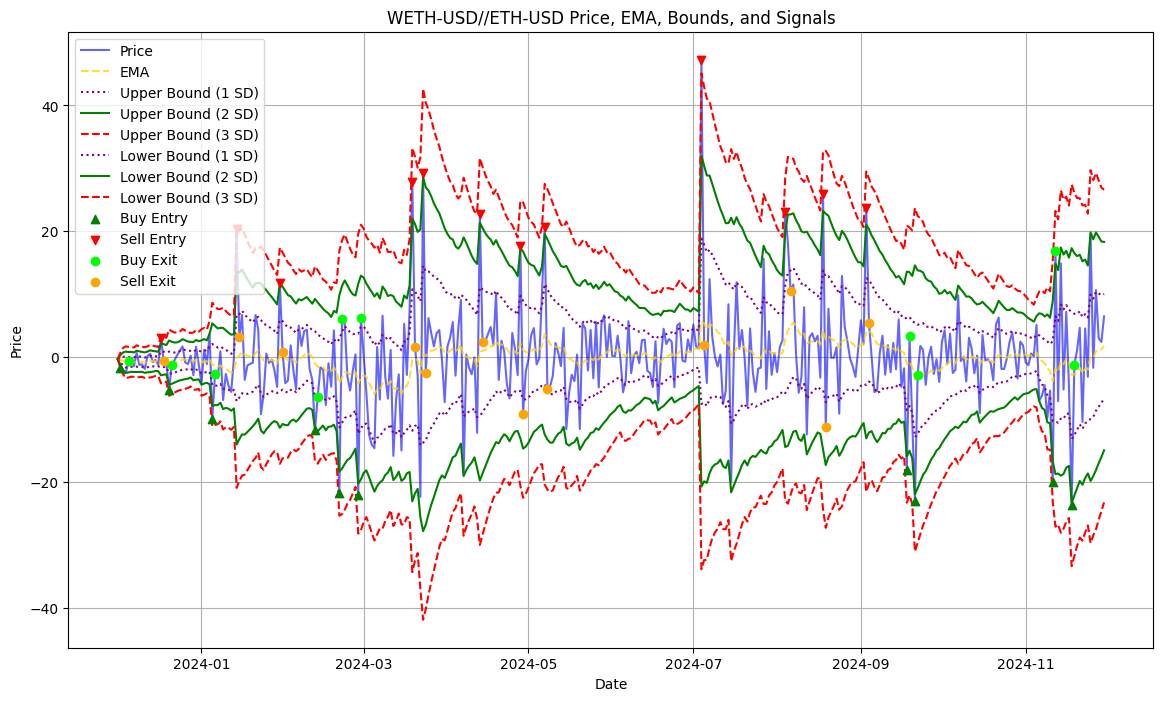

halflife: 9.998382920325522 Lookback: 29
Sharpe:  1.6132244541400902


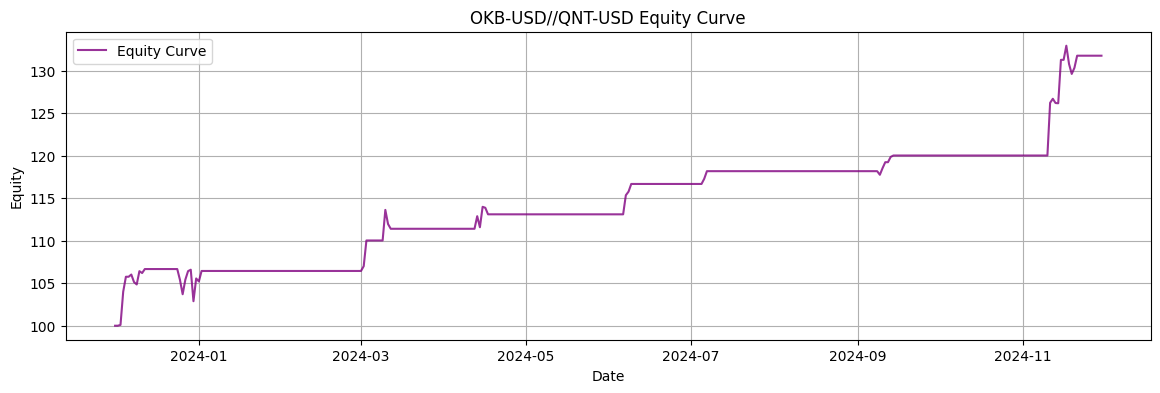

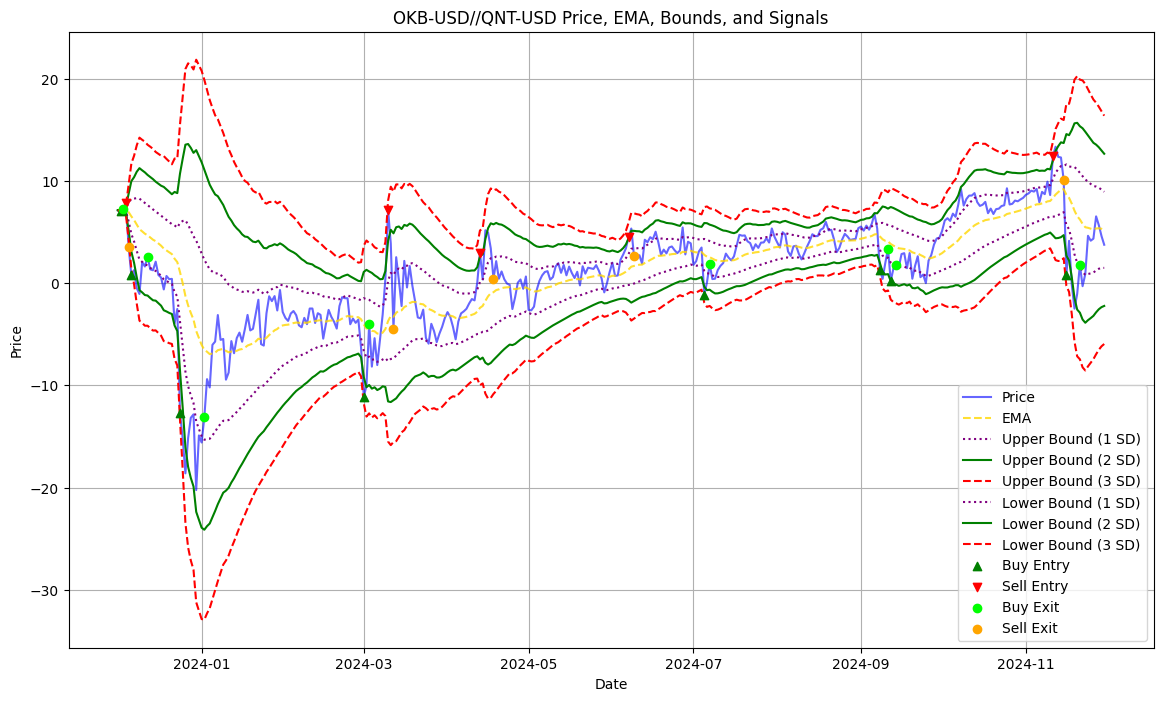

halflife: 8.56865349781287 Lookback: 25
Sharpe:  -16.121999793519244


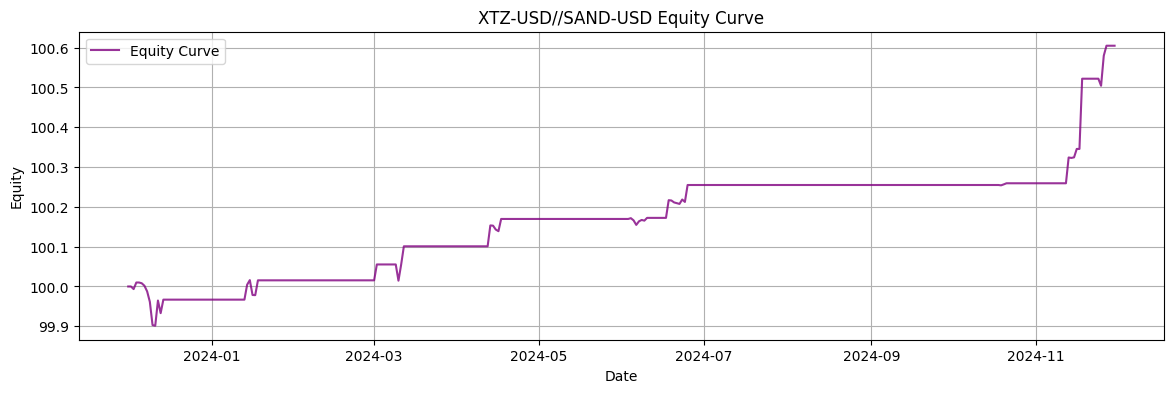

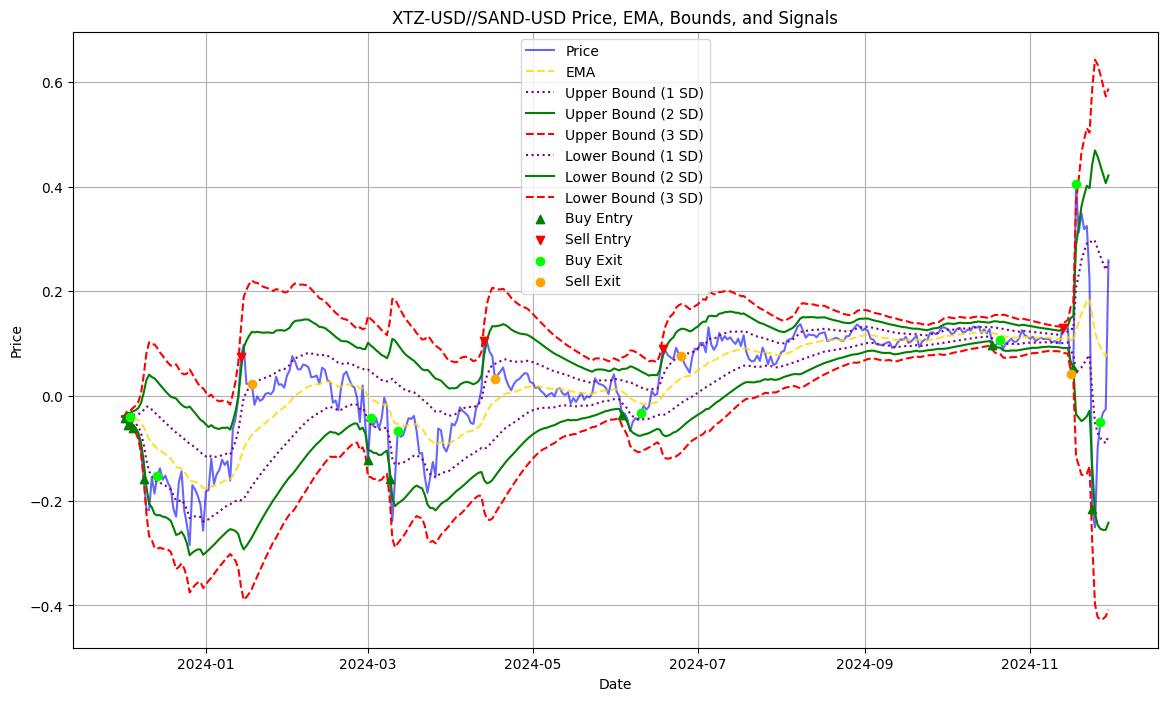

halflife: 10.270244069321091 Lookback: 20
Sharpe:  1.1871877079697495


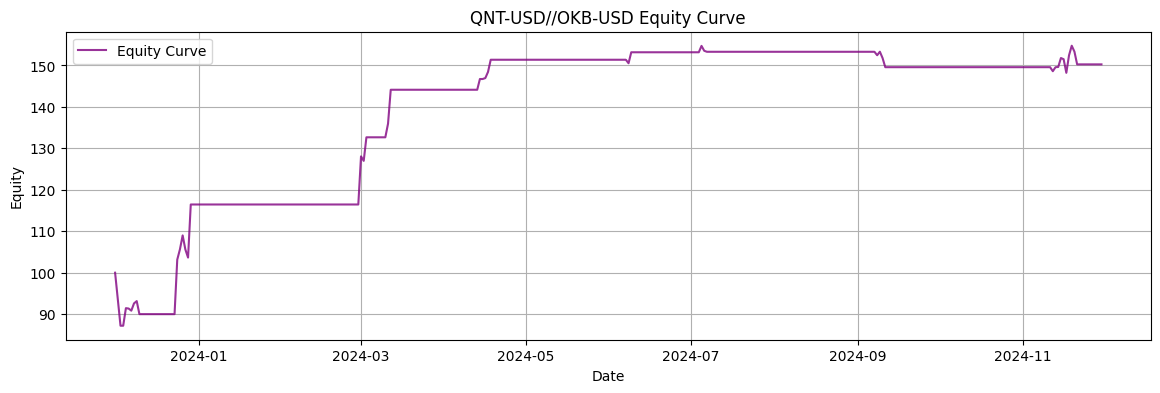

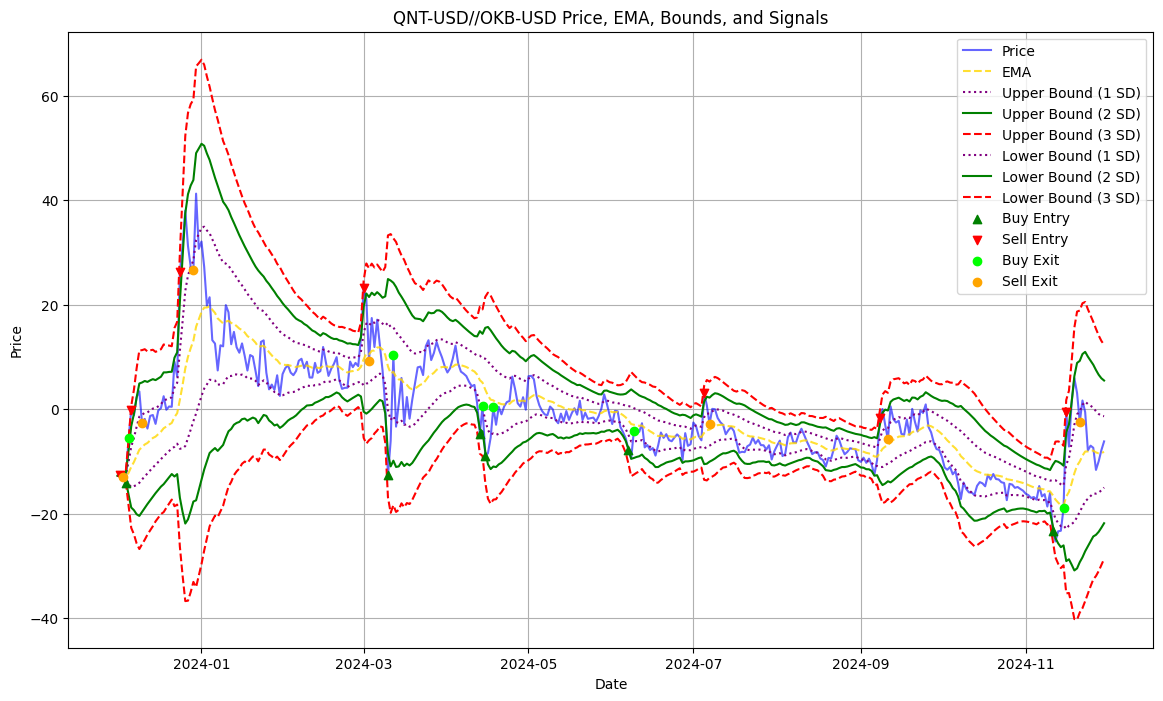

In [199]:
for combination in combined_series_df:
    serie = combined_series_df[combination]
    halflife = half_life(serie)
    lookback = find_lookback(halflife)
    equity, result = backtest(serie, lookback)
    print(f"halflife: {halflife} Lookback: {lookback}")
    print("Sharpe: ", sharpe_ratio(equity))
    plot_backtest_results(combination, result, equity)

# Part 6

In [173]:
def find_cointegrated_pairs_johansen(coin_1, coin_2, coin_3):
    coin_1_series = non_stationaries[coin_1].dropna()
    coin_2_series = non_stationaries[coin_2].dropna()
    coin_3_series = non_stationaries[coin_3].dropna()
    
    combined_coins_series = pd.concat([coin_1_series, coin_2_series, coin_3_series], axis=1).dropna()

    result = coint_johansen(combined_coins_series.values, det_order=0, k_ar_diff=1)

    cointegrating_vector = result.evec[:, 0]

    cointegrating_vector /= cointegrating_vector[0] # normalized

    return result.lr1 > result.cvt[:, 1], cointegrating_vector

In [174]:
cointegrated_pairs = []

for coin_1 in non_stationaries.columns:
    for coin_2 in non_stationaries.columns:
        for coin_3 in non_stationaries.columns:
            if coin_1 == coin_2 or coin_1 == coin_3 or coin_2 == coin_3:
                continue

            result = find_cointegrated_pairs_johansen(coin_1, coin_2, coin_3)
            status, coefficients = result
            
            if status.any():
                pair = (coin_1, coin_2, coin_3, coefficients)
                cointegrated_pairs.append(pair)

cointegrated_pairs

[('BTC-USD',
  'ETH-USD',
  'XRP-USD',
  array([ 1.00000000e+00, -6.81296598e+00,  1.37879362e+05])),
 ('BTC-USD',
  'ETH-USD',
  'STETH-USD',
  array([ 1.00000000e+00,  1.44653031e+04, -1.44773609e+04])),
 ('BTC-USD',
  'ETH-USD',
  'WSTETH-USD',
  array([   1.        ,  360.91526626, -320.96367202])),
 ('BTC-USD',
  'ETH-USD',
  'WBTC-USD',
  array([ 1.        ,  0.12578157, -1.00462078])),
 ('BTC-USD',
  'ETH-USD',
  'WETH-USD',
  array([ 1.00000000e+00,  2.80934797e+04, -2.80958991e+04])),
 ('BTC-USD',
  'ETH-USD',
  'LEO-USD',
  array([ 1.00000000e+00, -3.15202667e+00, -9.88848856e+03])),
 ('BTC-USD',
  'ETH-USD',
  'STX-USD',
  array([ 1.00000000e+00, -3.58680631e+01,  4.91780030e+06])),
 ('BTC-USD',
  'ETH-USD',
  'RETH-USD',
  array([   1.        ,  587.99470269, -543.41975676])),
 ('BTC-USD',
  'ETH-USD',
  'FLOKI-USD',
  array([ 1.00000000e+00,  2.12474608e+01, -3.02368049e+08])),
 ('BTC-USD',
  'XRP-USD',
  'ETH-USD',
  array([ 1.00000000e+00,  1.37879362e+05, -6.81296598e+0

In [175]:
hurst_results = []
combined_series = []

for pair in cointegrated_pairs:
    coin_1 = pair[0]
    coin_2 = pair[1]
    coin_3 = pair[2]
    coefficients = pair[3]
    c1, c2, c3 = coefficients[:]

    coin_1_series = non_stationaries[coin_1]
    coin_2_series = non_stationaries[coin_2]
    coin_3_series = non_stationaries[coin_3]

    combined_serie = c1 * coin_1_series + c2 * coin_2_series + c3 * coin_3_series
    combined_series.append((coin_1, coin_2, coin_3, combined_serie))

    hurst = hurst_exponent(combined_serie)
    hurst_results.append((coin_1, coin_2, coin_3, coefficients, hurst))

In [176]:
hurst_sorted = sorted(hurst_results, key=lambda x: x[4])[:5]

1. ETH-USD & RUNE-USD & STETH-USD - Hurst: -0.0168
2. STETH-USD & ETH-USD & RUNE-USD - Hurst: -0.0168
3. STETH-USD & RUNE-USD & ETH-USD - Hurst: -0.0168
4. RUNE-USD & STETH-USD & ETH-USD - Hurst: -0.0168
5. ETH-USD & STETH-USD & RUNE-USD - Hurst: -0.0168


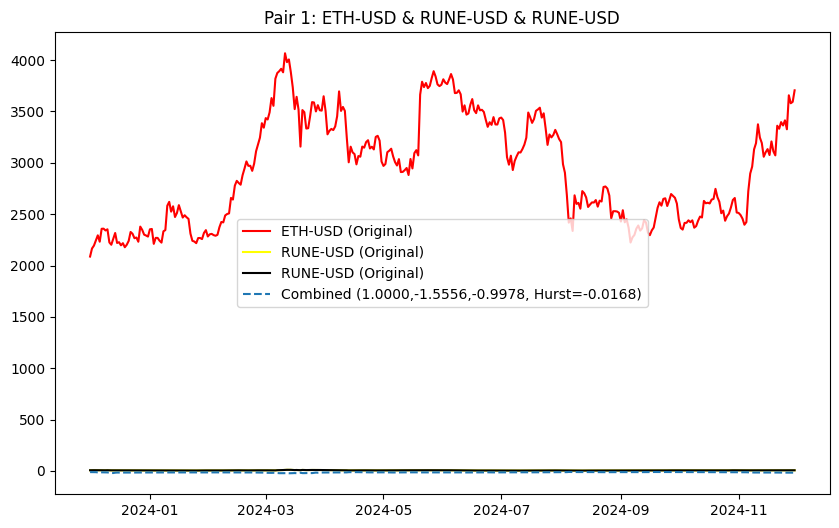

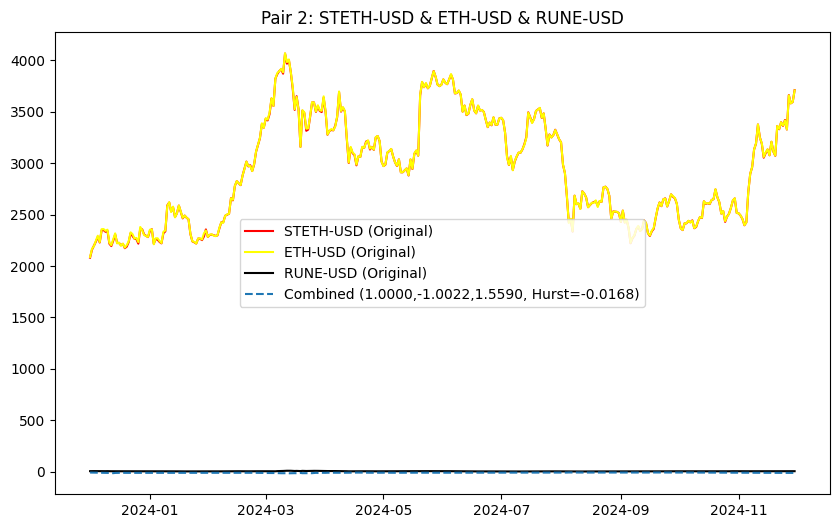

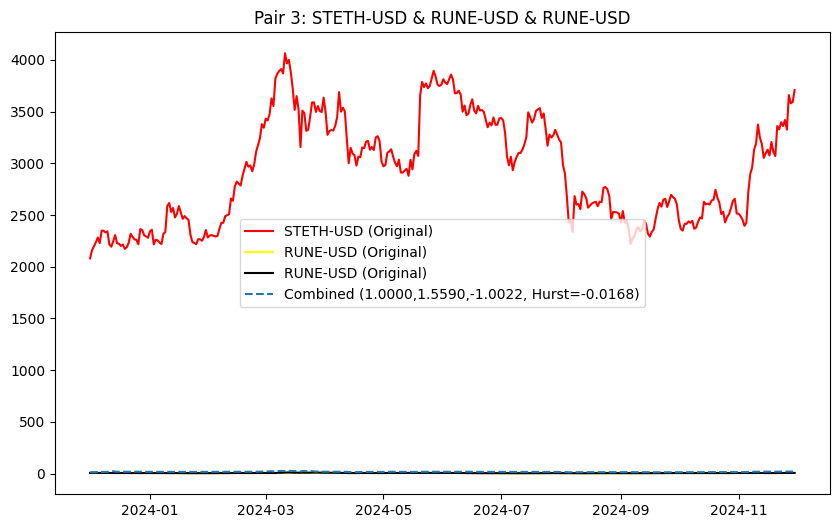

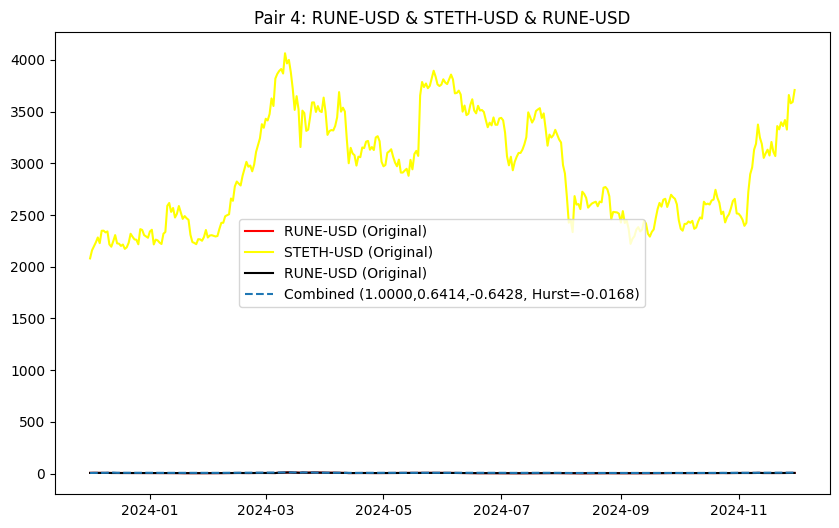

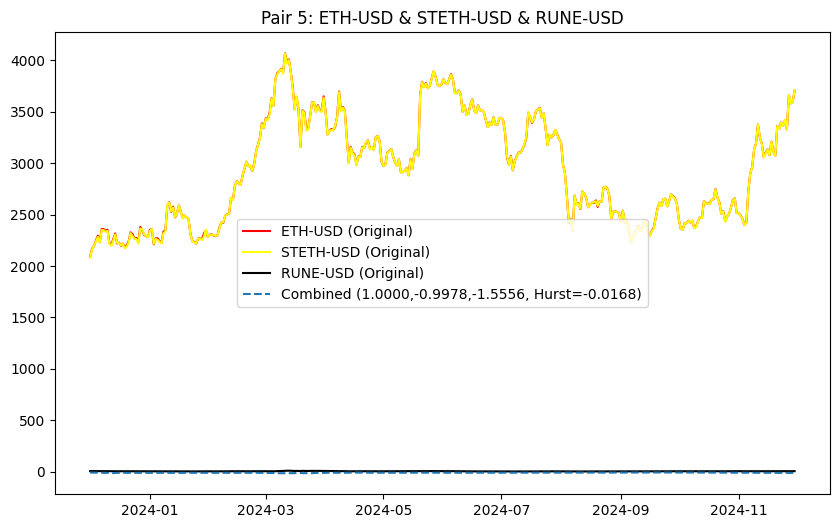

In [183]:
for i, (coin_1, coin_2, coin_3, coefficients, hurst) in enumerate(hurst_sorted):
    print(f"{i + 1}. {coin_1} & {coin_2} & {coin_3} - Hurst: {hurst:.4f}")

for i, (coin_1, coin_2, pvalue, coefficients, hurst) in enumerate(hurst_sorted):
    series1 = non_stationaries[coin_1]
    series2 = non_stationaries[coin_2]
    series3 = non_stationaries[coin_3]
    c1, c2, c3 = coefficients[:]

    combined_series = c1 * coin_1_series + c2 * coin_2_series + c3 * coin_3_series
    
    plt.figure(figsize=(10, 6))
    plt.plot(series1, label=f"{coin_1} (Original)", color='red')
    plt.plot(series2, label=f"{coin_2} (Original)", color='yellow')
    plt.plot(series3, label=f"{coin_3} (Original)", color='black')
    plt.plot(combined_series, label=f"Combined ({c1:.4f},{c2:.4f},{c3:.4f}, Hurst={hurst:.4f})", linestyle='--')
    plt.title(f"Pair {i + 1}: {coin_1} & {coin_2} & {coin_3}")
    plt.legend()
    plt.show()

In [181]:
combined_coins_beta = [(coin_1, coin_2, coin_3, coefficients) for coin_1, coin_2, coin_3, coefficients, _ in hurst_sorted]

combined_series_df = pd.DataFrame(index=non_stationaries.index)
for item in combined_coins_beta:
    coin_1 = item[0]
    coin_2 = item[1]
    coin_3 = item[2]
    coefficients = item[3]
    c1, c2, c3 = coefficients[:]
    combined_series_df[f"{coin_1}//{coin_2}//{coin_3}"] = c1 * non_stationaries[coin_1].values + c2 * non_stationaries[coin_2].values + c3 * non_stationaries[coin_3].values 
    
combined_series_df

,ETH-USD//RUNE-USD//STETH-USD,STETH-USD//ETH-USD//RUNE-USD,STETH-USD//RUNE-USD//ETH-USD,RUNE-USD//STETH-USD//ETH-USD,ETH-USD//STETH-USD//RUNE-USD
Date,,,,,
2023-12-01 00:00:00+00:00,1.024938,-1.027173,-1.027173,-0.658858,1.024938
2023-12-02 00:00:00+00:00,1.003235,-1.005422,-1.005422,-0.644906,1.003235
2023-12-03 00:00:00+00:00,-9.591973,9.612881,9.612881,6.165979,-9.591973
2023-12-04 00:00:00+00:00,1.633607,-1.637168,-1.637168,-1.050127,1.633607
2023-12-05 00:00:00+00:00,5.735427,-5.747929,-5.747929,-3.686887,5.735427
...,...,...,...,...,...
2024-11-26 00:00:00+00:00,-0.344247,0.344998,0.344998,0.221291,-0.344247
2024-11-27 00:00:00+00:00,-3.599203,3.607048,3.607048,2.313664,-3.599203
2024-11-28 00:00:00+00:00,-1.230454,1.233136,1.233136,0.790969,-1.230454


Sharpe:  2.3556143317348126


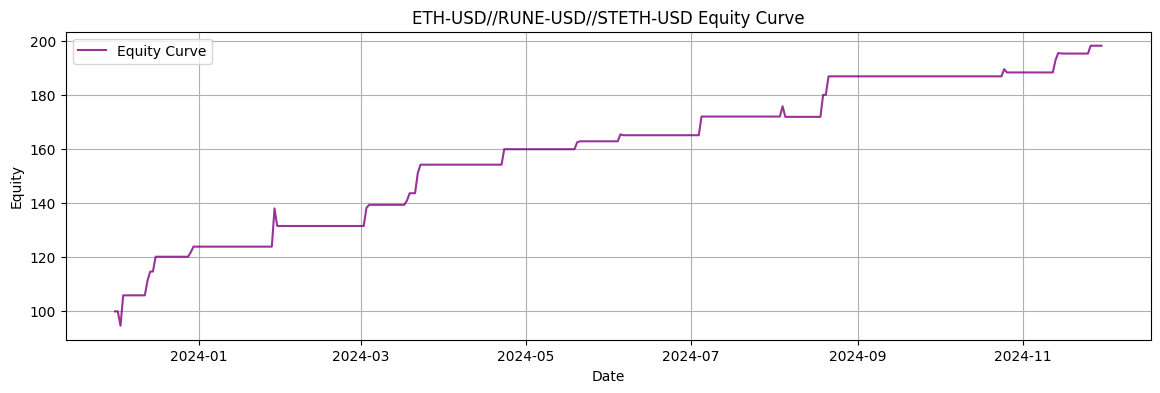

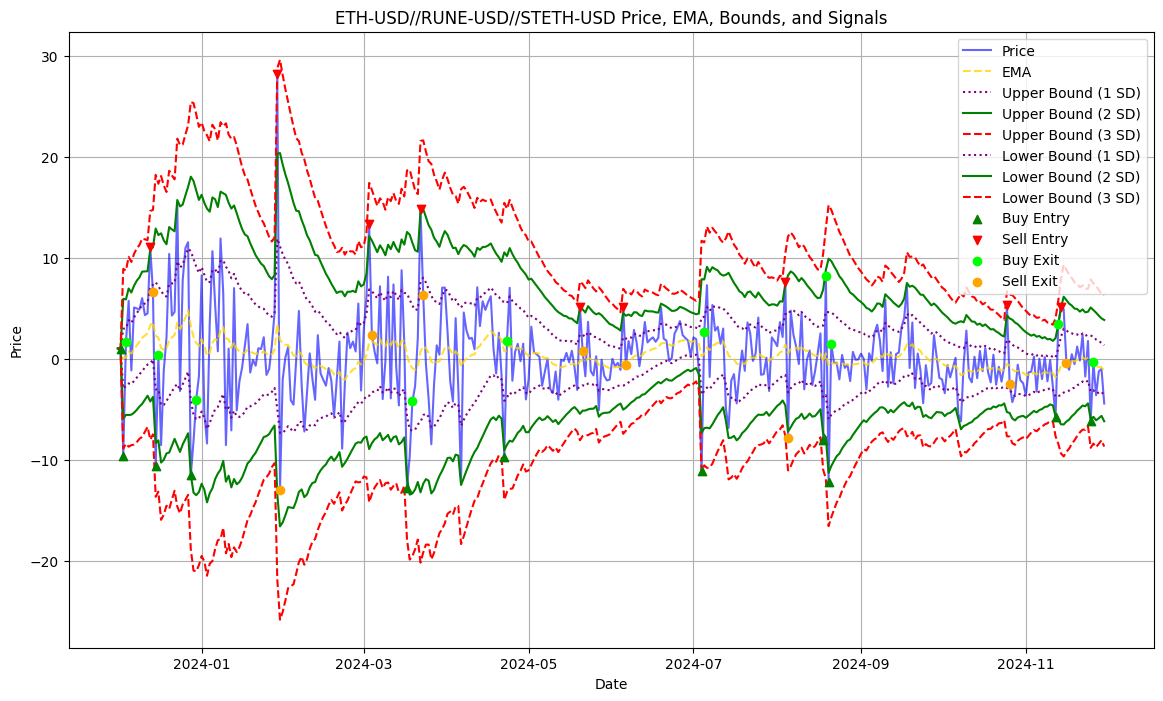

Sharpe:  1.7829681570442053


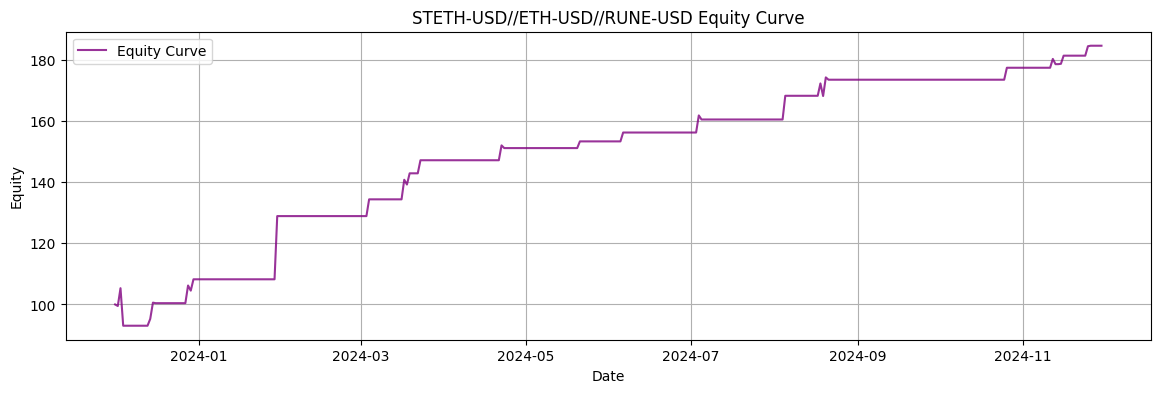

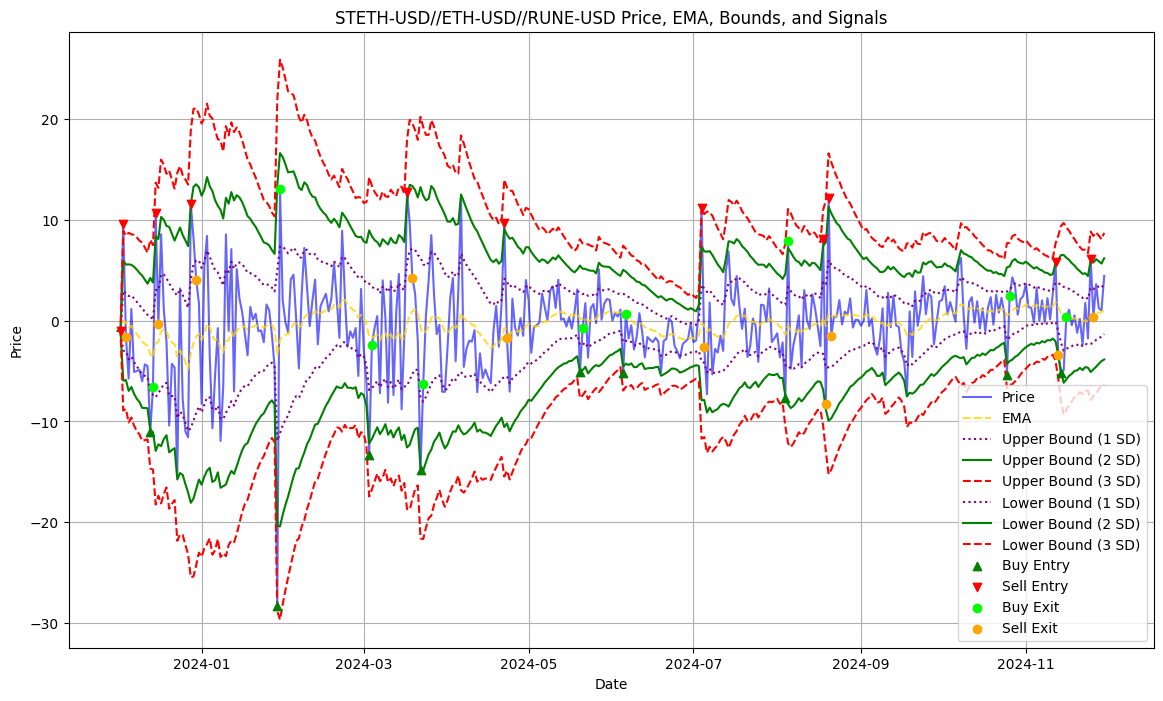

Sharpe:  1.78296815690618


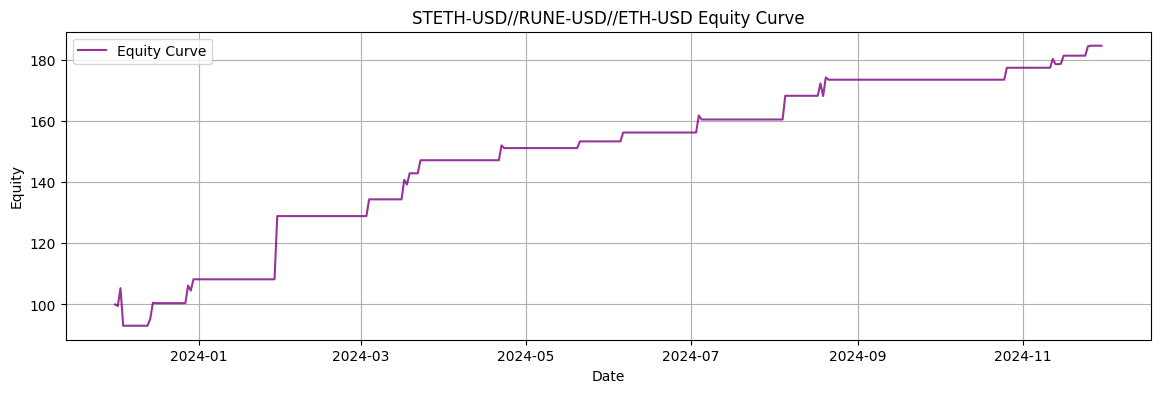

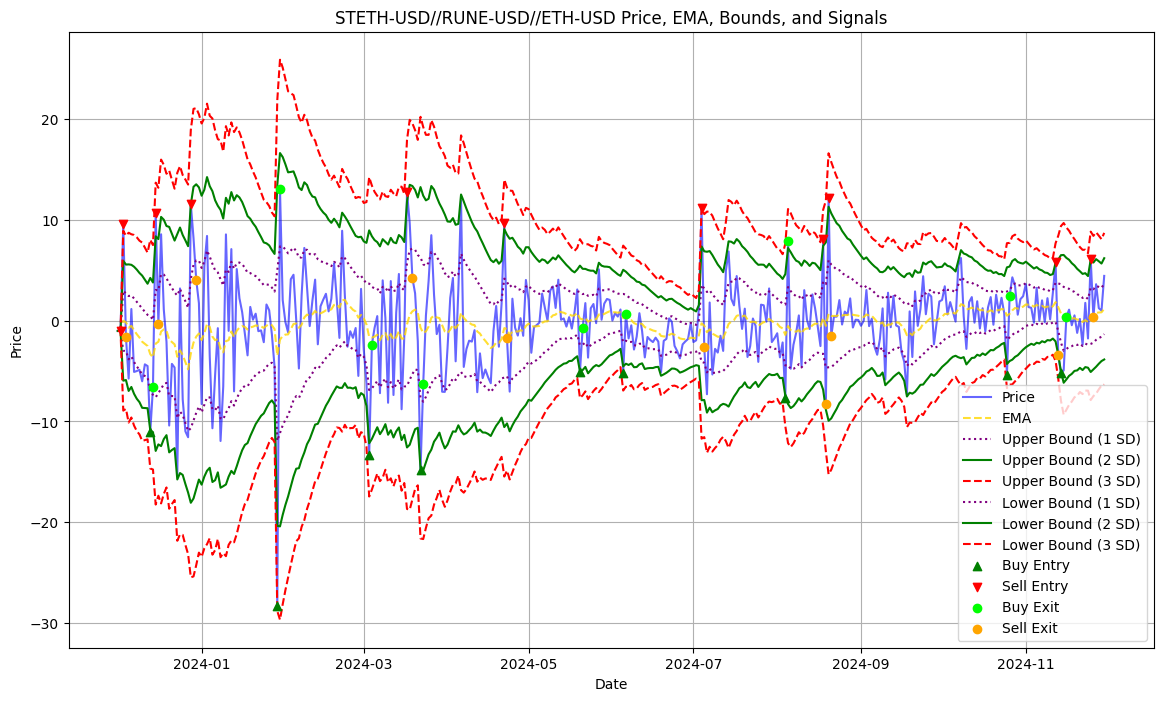

Sharpe:  1.7659151275377678


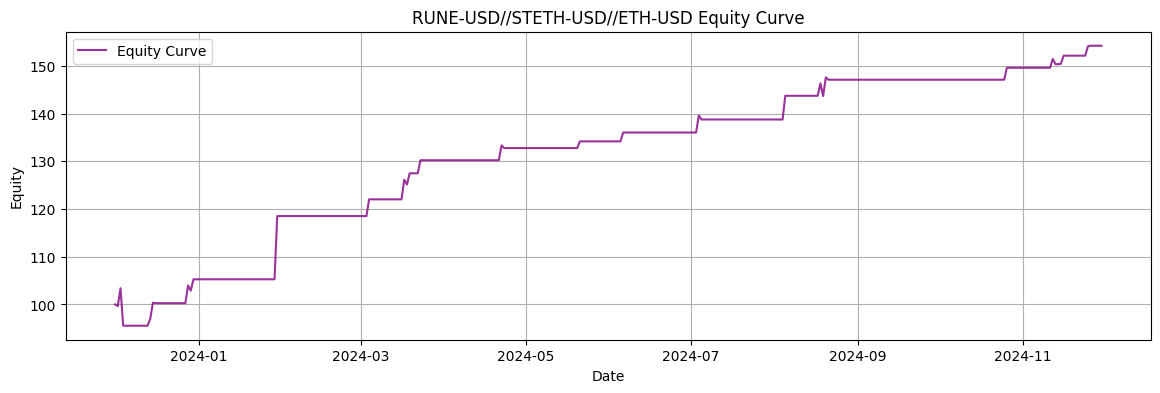

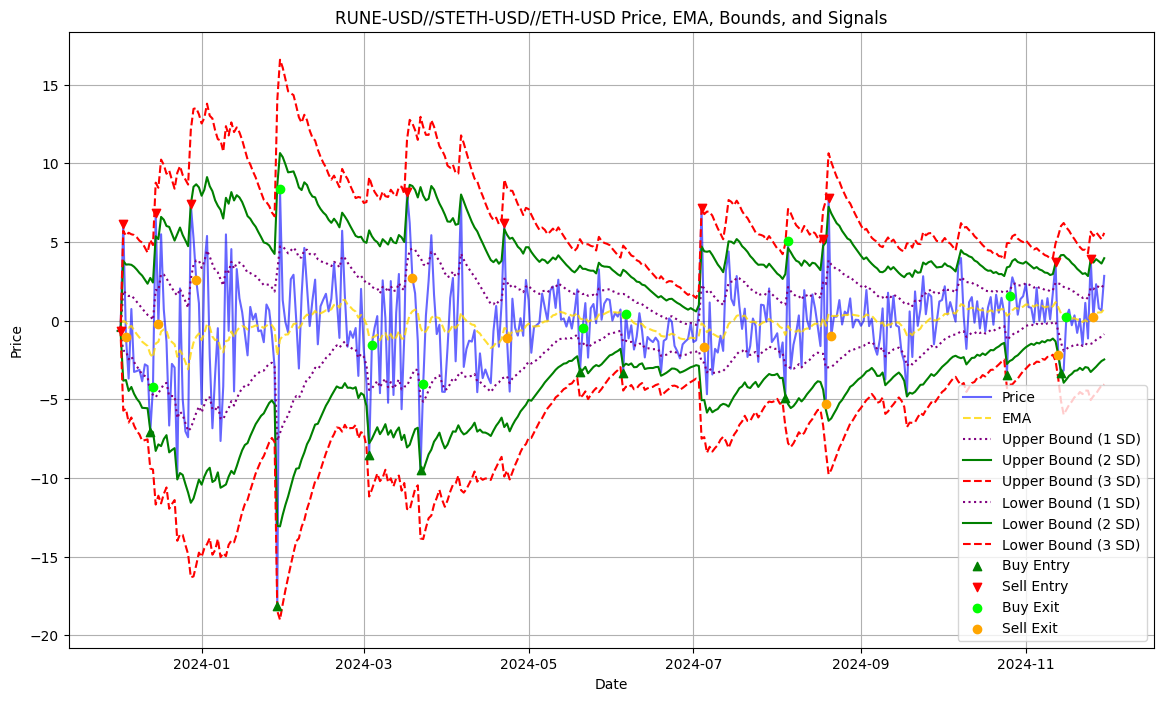

Sharpe:  2.3556143314690052


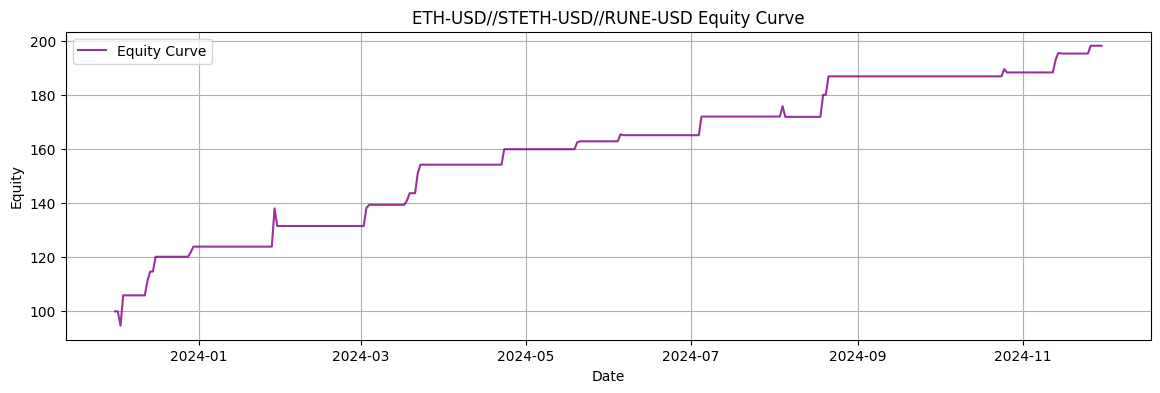

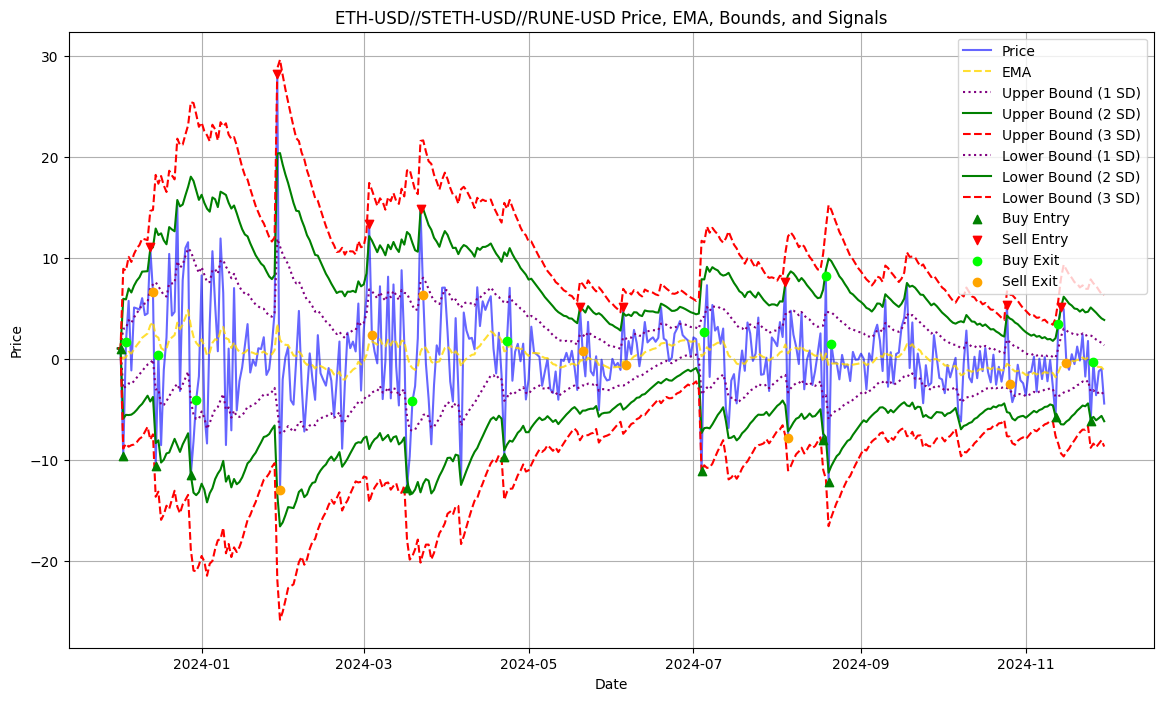

In [182]:
for combination in combined_series_df:
    serie = combined_series_df[combination]
    halflife = half_life(serie)
    lookback = find_lookback(halflife)
    equity, result = backtest(serie, lookback)
    # print(f"halflife: {halflife} Lookback: {lookback}")
    print("Sharpe: ", sharpe_ratio(equity))
    plot_backtest_results(combination, result, equity)